In [1]:
%pip install requests


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
"""
Age Composition & Manufacturing Decline
Interaction with Baseline Healthcare Employment Share
====================================================

This script downloads county‐level U.S. data and runs the cross-sectional regression

    ΔShare65+ (2010→2022) = β₀ + β₁·ΔManufacturingEmp + β₂·HighHC +
                              β₃·(ΔManufacturingEmp × HighHC) + ε ,

where
* **ΔManufacturingEmp** = (manufacturing employment 2022 – 2010) ÷ 1 000
  (NAICS 31-33, County Business Patterns – CBP).
* **HighHC** = 1 if the county’s 2010 share of workers in **Healthcare & Social
  Assistance** (NAICS 62) is **above the median**; 0 otherwise.

Data sources
------------
* **American Community Survey (ACS) 5-year** summary files
  * 2010 (2006-10) – baseline age composition
  * 2022 (2018-22) – current age composition
* **County Business Patterns (CBP)**
  * Employment for:
    * Total employment (NAICS 00) in 2010
    * Healthcare & Social Assistance (NAICS 62) in 2010
    * Manufacturing (NAICS 31-33) in 2010 and 2022

Requirements
------------
Python ≥ 3.9 plus

    pip install pandas requests statsmodels numpy tqdm

Optionally export a free Census API key:

    export CENSUS_API_KEY="YOUR_KEY"

Running the script prints the HC-robust regression table and writes:
* `age_manuf_ols.pickle` – serialized `statsmodels` result
* `county_level_dataset.csv` – analysis dataset
"""

import os
from typing import List
import requests
import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm import tqdm

###############################################################################
# Configuration
###############################################################################

CENSUS_KEY = "488b0df48f856b207eae540095aee8cd37926d3a"
BASE = "https://api.census.gov/data/{year}/{dataset}"

# --- ACS variables for age composition (male + female 65-85+)
ACS_AGE_VARS: List[str] = [
    # Male 65-66 … 85+
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    # Female 65-66 … 85+
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",
    # Total population
    "B01001_001E",
]

###############################################################################
# Helper functions
###############################################################################

def fetch_acs(year: int, variables: List[str]) -> pd.DataFrame:
    """Pull ACS 5-year data for all counties."""
    url = BASE.format(year=year, dataset="acs/acs5")
    params = {
        "get": ",".join(["NAME"] + variables),
        "for": "county:*",
    }
    if CENSUS_KEY:
        params["key"] = CENSUS_KEY
    resp = requests.get(url, params=params, timeout=120)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    for v in variables:
        df[v] = pd.to_numeric(df[v], errors="coerce")
    df["fips"] = df["state"] + df["county"]
    return df.set_index("fips")


def fetch_cbp(year: int, naics: str) -> pd.DataFrame:
    """Fetch CBP employment for a NAICS code (string like '31-33' or '62' or '00')."""
    url = BASE.format(year=year, dataset="cbp")
    params = {
        "get": "EMP,NAME",
        "for": "county:*",
        "NAICS": naics,
    }
    if CENSUS_KEY:
        params["key"] = CENSUS_KEY
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    rows = r.json()
    df = pd.DataFrame(rows[1:], columns=rows[0])
    df["EMP"] = pd.to_numeric(df["EMP"], errors="coerce")
    df["fips"] = df["state"] + df["county"]
    df = df[["fips", "EMP"]]
    col = f"emp_{naics.replace('-', '_')}_{year}"
    return df.rename(columns={"EMP": col}).set_index("fips")

###############################################################################
# Download datasets
###############################################################################

print("Downloading ACS 2010 & 2022 …")
acs10 = fetch_acs(2010, ACS_AGE_VARS)
acs22 = fetch_acs(2022, ACS_AGE_VARS)

print("Downloading CBP employment files …")
man10 = fetch_cbp(2010, "31-33")
man22 = fetch_cbp(2022, "31-33")
health10 = fetch_cbp(2010, "62")

# Total employment (NAICS 00)
try:
    total10 = fetch_cbp(2010, "00")
except Exception:
    # Fallback: NAICS '--' sometimes used for total in older CBP; try that if needed
    total10 = fetch_cbp(2010, "--")

###############################################################################
# Build variables
###############################################################################

def share65(df: pd.DataFrame, year: int) -> pd.Series:
    seniors = df[ACS_AGE_VARS[:-1]].sum(axis=1)
    share = seniors / df["B01001_001E"]
    return share.rename(f"share65_{year}")

share65_10 = share65(acs10, 2010)
share65_22 = share65(acs22, 2022)

df = pd.concat([
    share65_10,
    share65_22,
    man10,
    man22,
    health10,
    total10,
], axis=1, join="inner")

# Replace suppressed/NA with 0 for employment
emp_cols = [c for c in df.columns if c.startswith("emp_")]
df[emp_cols] = df[emp_cols].fillna(0)

# Δ manufacturing employment (per 1 000)
df["delta_manuf_emp"] = (df["emp_31_33_2022"] - df["emp_31_33_2010"]) / 1_000

# Healthcare employment share 2010
with np.errstate(divide="ignore", invalid="ignore"):
    df["hc_share_2010"] = df["emp_62_2010"] / df["emp_00_2010"].replace(0, np.nan)

df["hc_share_2010"].fillna(0, inplace=True)

# HighHC dummy
median_hc = df["hc_share_2010"].median()
df["high_HC"] = (df["hc_share_2010"] >= median_hc).astype(int)

# Interaction
df["interact"] = df["delta_manuf_emp"] * df["high_HC"]

# Outcome Δ share 65+
df["delta_share65"] = df["share65_22"] - df["share65_10"]

###############################################################################
# OLS regression
###############################################################################

y = df["delta_share65"]
X = df[["delta_manuf_emp", "high_HC", "interact"]]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type="HC1")
print(model.summary())

# Persist
model.save("age_manuf_ols.pickle")
df.to_csv("county_level_dataset.csv")

print("\nSaved age_manuf_ols.pickle and county_level_dataset.csv")

KeyboardInterrupt: 

# Gemini - ACS 2010-present


--- Fetching Data for T1 (2010) ---
Fetching data for 2010 from acs/acs5/subject (variables: S0101_C01_001E,S0101_C01_030E)...
Successfully fetched 955 records.
Fetching data for 2010 from acs/acs5/subject (variables: S2401_C01_001E,S2401_C01_009E,S2401_C01_016E,S2401_C01_017E)...
Successfully fetched 955 records.

--- Fetching Data for T2 (2019) ---
Fetching data for 2019 from acs/acs5/subject (variables: S0101_C01_001E,S0101_C01_030E)...
Successfully fetched 938 records.
Fetching data for 2019 from acs/acs5/subject (variables: S2401_C01_001E,S2401_C01_009E)...
Successfully fetched 938 records.

Number of MSAs after cleaning and merging: 779
Number of MSAs that gained or lost manufacturing: 779
Number of MSAs in final regression: 779

Running OLS regression with controls: Delta_Share65 ~ ManufLoss*HealthcareShare_t1 + Share65_t1 + LogTotalOverallPop_t1
                            OLS Regression Results                            
Dep. Variable:          Delta_Share65   R-squared:    

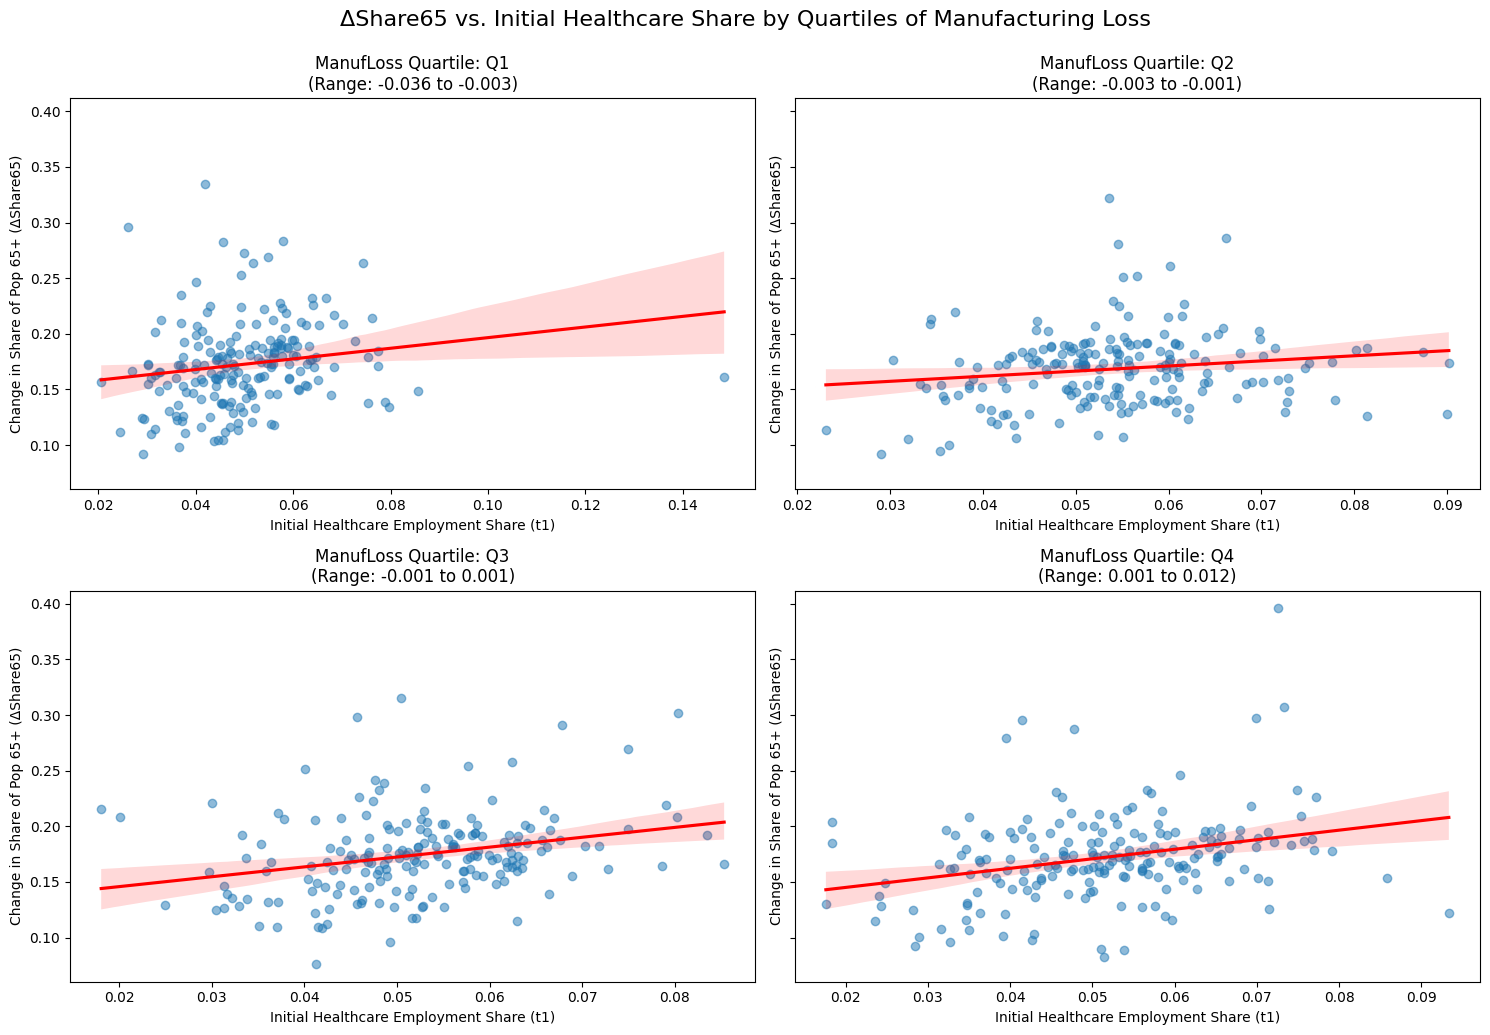

Visualization generated. If it doesn't appear, ensure your environment supports GUI plots.


In [ ]:
import pandas as pd
import requests
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# !! IMPORTANT: Replace with your actual Census API Key !!
CENSUS_API_KEY = "488b0df48f856b207eae540095aee8cd37926d3a" # Get one from: https://api.census.gov/data/key_signup.html

YEAR_T1 = "2010" # ACS 5-year estimates for 2006-2010
YEAR_T2 = "2019" # ACS 5-year estimates for 2015-2019

# --- Helper Function to Fetch and Process Census Data ---
def get_census_data(year, dataset_endpoint, variable_list_str, api_key):
    """
    Fetches data from the Census Bureau API for a given year, dataset, and variables.
    Dataset endpoint will be 'acs/acs5/subject'.
    """
    base_url = f"https://api.census.gov/data/{year}/{dataset_endpoint}"
    params = {
        "get": f"NAME,{variable_list_str}",
        "for": "metropolitan statistical area/micropolitan statistical area:*",
        "key": api_key
    }
    
    print(f"Fetching data for {year} from {dataset_endpoint} (variables: {variable_list_str})...")
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()  # Raise an exception for HTTP errors
        data = response.json()
        df = pd.DataFrame(data[1:], columns=data[0])
        if 'metropolitan statistical area/micropolitan statistical area' in df.columns:
            df.rename(columns={'metropolitan statistical area/micropolitan statistical area': 'GEO_ID'}, inplace=True)
        elif 'GEO_ID' not in df.columns and 'geoid' in df.columns:
             df.rename(columns={'geoid': 'GEO_ID'}, inplace=True)
        
        print(f"Successfully fetched {len(df)} records.")
        return df
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for {year} from {dataset_endpoint}: {e}")
        if response: print(f"Response content: {response.text}")
        return None
    except ValueError as e:
        print(f"Error parsing JSON for {year} from {dataset_endpoint}: {e}")
        if response: print(f"Response content: {response.text}")
        return None

# --- Main Analysis ---
if CENSUS_API_KEY == "YOUR_API_KEY_HERE": # User should replace this with their actual key
    print("Please replace 'YOUR_API_KEY_HERE' with your actual Census API key and rerun the script.")
else:
    # Variables for Age Data (Table S0101)
    vars_age_data = "S0101_C01_001E,S0101_C01_030E" # TotalPop, Pop65+

    # Variables for Industry Employment Data (Table S2401)
    # For t1: TotalEmp, ManufEmp, and specific healthcare components
    # S2401_C01_016E: Hospitals
    # S2401_C01_017E: Health services, except hospitals
    hc_components_t1 = ["S2401_C01_016E", "S2401_C01_017E"]
    vars_industry_t1_list = ["S2401_C01_001E", "S2401_C01_009E"] + hc_components_t1
    vars_industry_t1 = ",".join(vars_industry_t1_list)
    
    # For t2: TotalEmp, ManufEmp (no healthcare needed from t2 for this analysis)
    vars_industry_t2 = "S2401_C01_001E,S2401_C01_009E"

    # --- Fetch data for t1 ---
    print(f"\n--- Fetching Data for T1 ({YEAR_T1}) ---")
    df_age_t1 = get_census_data(YEAR_T1, "acs/acs5/subject", vars_age_data, CENSUS_API_KEY)
    df_industry_t1 = get_census_data(YEAR_T1, "acs/acs5/subject", vars_industry_t1, CENSUS_API_KEY)

    # --- Fetch data for t2 ---
    print(f"\n--- Fetching Data for T2 ({YEAR_T2}) ---")
    df_age_t2 = get_census_data(YEAR_T2, "acs/acs5/subject", vars_age_data, CENSUS_API_KEY)
    df_industry_t2 = get_census_data(YEAR_T2, "acs/acs5/subject", vars_industry_t2, CENSUS_API_KEY)

    if df_age_t1 is not None and df_industry_t1 is not None and \
       df_age_t2 is not None and df_industry_t2 is not None:

        df_t1 = pd.merge(df_age_t1, df_industry_t1, on=["GEO_ID", "NAME"], suffixes=('_age', '_industry'))
        df_t2 = pd.merge(df_age_t2, df_industry_t2, on=["GEO_ID", "NAME"], suffixes=('_age', '_industry'))

        cols_t1_rename = {
            "S0101_C01_001E": "TotalOverallPop_t1", "S0101_C01_030E": "Pop65_t1",
            "S2401_C01_001E": "TotalEmp_t1", "S2401_C01_009E": "ManufEmp_t1",
        }
        cols_t2_rename = {
            "S0101_C01_001E": "TotalOverallPop_t2", "S0101_C01_030E": "Pop65_t2",
            "S2401_C01_001E": "TotalEmp_t2", "S2401_C01_009E": "ManufEmp_t2"
        }
        df_t1.rename(columns=cols_t1_rename, inplace=True)
        df_t2.rename(columns=cols_t2_rename, inplace=True)
        
        df_t1_select_cols = ["GEO_ID", "NAME", "TotalOverallPop_t1", "Pop65_t1", 
                               "TotalEmp_t1", "ManufEmp_t1"] + hc_components_t1
        df_t1_select = df_t1[df_t1_select_cols]
        df_t2_select = df_t2[["GEO_ID", "NAME", "TotalOverallPop_t2", "Pop65_t2", 
                               "TotalEmp_t2", "ManufEmp_t2"]]
        
        df_merged = pd.merge(df_t1_select, df_t2_select, on=["GEO_ID", "NAME"])

        numeric_cols_to_convert = ["TotalOverallPop_t1", "Pop65_t1", "TotalEmp_t1", "ManufEmp_t1"] + \
                                  hc_components_t1 + \
                                  ["TotalOverallPop_t2", "Pop65_t2", "TotalEmp_t2", "ManufEmp_t2"]
        
        for col in numeric_cols_to_convert:
            df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

        df_merged['HealthcareEmp_t1'] = df_merged[hc_components_t1[0]] + df_merged[hc_components_t1[1]]

        cols_for_dropna = ["TotalOverallPop_t1", "Pop65_t1", "TotalEmp_t1", "ManufEmp_t1", "HealthcareEmp_t1",
                           "TotalOverallPop_t2", "Pop65_t2", "TotalEmp_t2", "ManufEmp_t2"]
        df_merged.dropna(subset=cols_for_dropna, inplace=True)
        
        print(f"\nNumber of MSAs after cleaning and merging: {len(df_merged)}")

        if len(df_merged) < 20:
             print("Insufficient data for analysis after cleaning. Check API calls and data availability.")
        else:
            df_merged['Share65_t1'] = df_merged['Pop65_t1'] / df_merged['TotalOverallPop_t1']
            df_merged['Share65_t2'] = df_merged['Pop65_t2'] / df_merged['TotalOverallPop_t2']
            df_merged['Delta_Share65'] = df_merged['Share65_t2'] - df_merged['Share65_t1']

            df_merged['ManufShare_t1'] = df_merged['ManufEmp_t1'] / df_merged['TotalEmp_t1']
            df_merged['ManufShare_t2'] = df_merged['ManufEmp_t2'] / df_merged['TotalEmp_t2']
            
            df_merged['ManufLoss'] = df_merged['ManufShare_t1'] - df_merged['ManufShare_t2']
            
            # (1) Use continuous HealthcareShare_t1
            df_merged['HealthcareShare_t1'] = df_merged['HealthcareEmp_t1'] / df_merged['TotalEmp_t1']
            
            df_analysis = df_merged.copy()
            print(f"Number of MSAs that gained or lost manufacturing: {len(df_analysis)}")

            if len(df_analysis) < 20:
                print("Insufficient data for regression after filtering for manufacturing loss.")
            else:
                df_analysis.replace([np.inf, -np.inf], np.nan, inplace=True)
                # Use HealthcareShare_t1 instead of Initial_HC_High
                final_cols_check = ['Delta_Share65', 'ManufLoss', 'HealthcareShare_t1', 'Share65_t1', 'TotalOverallPop_t1']
                df_analysis.dropna(subset=final_cols_check, inplace=True)
                
                df_analysis = df_analysis[df_analysis['TotalOverallPop_t1'] > 0].copy()
                df_analysis['TotalOverallPop_t1'] = df_analysis['TotalOverallPop_t1']
                
                df_analysis.replace([np.inf, -np.inf], np.nan, inplace=True)
                df_analysis.dropna(subset=['TotalOverallPop_t1'] + final_cols_check, inplace=True)

                print(f"Number of MSAs in final regression: {len(df_analysis)}")

                if len(df_analysis) < 20:
                     print("Insufficient data for regression after final cleaning for controls.")
                else:
                    # (1) Updated model formula to use continuous HealthcareShare_t1
                    model_formula_controlled = 'Delta_Share65 ~ ManufLoss*HealthcareShare_t1 + Share65_t1 + TotalOverallPop_t1'
                    print(f"\nRunning OLS regression with controls: {model_formula_controlled}")
                    
                    model = smf.ols(formula=model_formula_controlled, data=df_analysis).fit()
                    print(model.summary())

                    print("\n--- Interpretation of Key Coefficients (HC Share = Continuous Healthcare Employment Share_t1) ---")
                    print(f"ManufLoss: How much ΔShare65+ changes for a one-unit increase in ManufLoss, holding other variables constant.")
                    print(f"HealthcareShare_t1: How much ΔShare65+ changes for a one-unit increase in the initial Healthcare Employment Share (t1), holding other variables constant.")
                    
                    # (2) Visualize the regression as 4 panels
                    print("\n--- Generating Visualization ---")
                    df_analysis_viz = df_analysis.dropna(subset=['Delta_Share65', 'HealthcareShare_t1', 'ManufLoss']).copy() # Ensure no NaNs for viz variables

                    if len(df_analysis_viz) < 4: # Need enough data to form quartiles
                        print("Insufficient data to generate quartile-based visualization.")
                    else:
                        # Create quartiles for ManufLoss
                        try:
                            df_analysis_viz['ManufLoss_Quartile'] = pd.qcut(df_analysis_viz['ManufLoss'], 4, labels=[f"Q{i}" for i in range(1, 5)])
                        except ValueError as e:
                            print(f"Could not create 4 quartiles for ManufLoss (e.g., too few unique values or not enough data points): {e}")
                            print("Attempting to plot without quartiles if this is the case, or check data.")
                            # As a fallback, could plot all data if quartiling fails, or just skip. Here, we'll try to proceed or just warn.
                            df_analysis_viz['ManufLoss_Quartile'] = "AllData" # Fallback if qcut fails

                        
                        # Create 2x2 panel plot
                        fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True) # sharey can be useful
                        axes = axes.flatten() # Flatten to 1D array for easy iteration

                        quartiles = df_analysis_viz['ManufLoss_Quartile'].unique()
                        quartiles = sorted(quartiles) # This will sort the Categorical object or a NumPy array (fallback case)
                        for i, quartile in enumerate(quartiles):
                            if i >= 4: break # Only plot up to 4 panels
                            ax = axes[i]
                            data_quartile = df_analysis_viz[df_analysis_viz['ManufLoss_Quartile'] == quartile]
                            
                            if not data_quartile.empty:
                                sns.regplot(x='HealthcareShare_t1', y='Delta_Share65', data=data_quartile, ax=ax,
                                            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
                                min_loss = data_quartile['ManufLoss'].min()
                                max_loss = data_quartile['ManufLoss'].max()
                                ax.set_title(f'ManufLoss Quartile: {quartile}\n(Range: {min_loss:.3f} to {max_loss:.3f})')
                                ax.set_xlabel('Initial Healthcare Employment Share (t1)')
                                ax.set_ylabel('Change in Share of Pop 65+ (ΔShare65)')
                            else:
                                ax.set_title(f'ManufLoss Quartile: {quartile}\n(No data)')
                                ax.set_xlabel('Initial Healthcare Employment Share (t1)')
                                ax.set_ylabel('Change in Share of Pop 65+ (ΔShare65)')
                        
                        # Hide any unused subplots if fewer than 4 quartiles were plotted (e.g. if qcut failed and we only have "AllData")
                        for j in range(i + 1, 4):
                            fig.delaxes(axes[j])

                        plt.tight_layout()
                        plt.suptitle('ΔShare65 vs. Initial Healthcare Share by Quartiles of Manufacturing Loss', fontsize=16, y=1.03)
                        plt.savefig('share65_manufacturing.png', dpi=300, bbox_inches='tight')
                        
                        plt.show()
                        print("Visualization generated. If it doesn't appear, ensure your environment supports GUI plots.")

    else:
        print("\nOne or more data fetching steps failed. Cannot proceed with analysis.")

# to do:

# Extend time series back further
# Make sure you believe the measure for healthcare
# .. same for manufacturing
# .. add in more controls?

# moreso, apples to apples.

=== Manufacturing Decline Analysis (2000-2020) ===
Using CBP 2000 and 2020 for consistency

STEP 1: Checking for CBP data files...
------------------------------------------------------------
✓ Found cbp00co.zip
Loaded 726913 records from CBP 2000
Columns: ['fipstate', 'fipscty', 'naics', 'empflag', 'emp', 'qp1', 'ap', 'est', 'n1_4', 'n5_9', 'n10_19', 'n20_49', 'n50_99', 'n100_249', 'n250_499', 'n500_999', 'n1000', 'n1000_1', 'n1000_2', 'n1000_3', 'n1000_4', 'censtate', 'cencty', 'county_fips']

Processing CBP 2000 data...
Total records: 726913
Counties: 3174
Counties with total employment: 3166
Manufacturing records - 31: 2695, 32: 0, 33: 0
Processed employment data for 3166 counties
Average manufacturing share: 0.182
Average healthcare share: 0.137

Fetching Census 2000 population data via API...
Successfully fetched Census 2000 data for 3219 counties

Counties in regression: 3114
                            OLS Regression Results                            
Dep. Variable:          D

/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_9397/2596763097.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i,(q,g) in enumerate(df.groupby('ManufLoss_Q')):


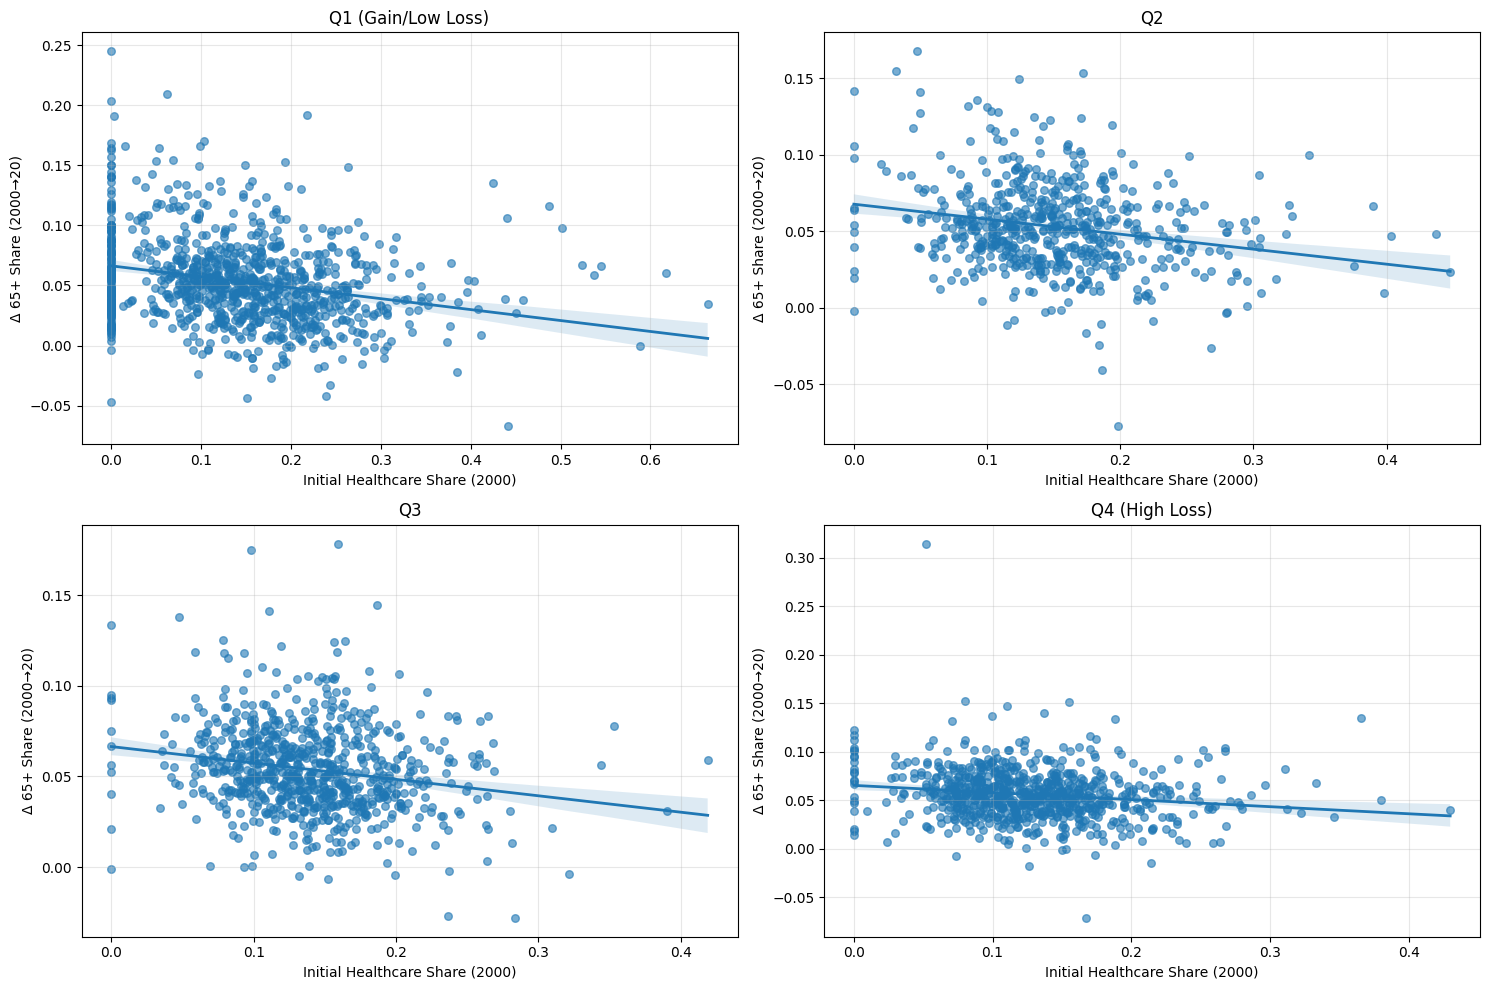

In [74]:
import pandas as pd
import requests
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# --- Configuration ---
CENSUS_API_KEY = "488b0df48f856b207eae540095aee8cd37926d3a"

print("=== Manufacturing Decline Analysis (2000-2020) ===")
print("Using CBP 2000 and 2020 for consistency\n")

# --- STEP 1: Check for data files ---
print("STEP 1: Checking for CBP data files...")
print("-" * 60)

# Check if 2000 file exists
if not os.path.exists('cbp00co.zip'):
    print("ERROR: cbp00co.zip not found!")
    print("Please download from: https://www2.census.gov/programs-surveys/cbp/datasets/2000/cbp00co.zip")
    print("Save as: cbp00co.zip in your working directory")
    exit()
else:
    print("✓ Found cbp00co.zip")

# --- Helper Functions for 2000 Data ---
def read_cbp_2000_county_data(zip_path='cbp00co.zip'):
    """Read the 2000 CBP county data from downloaded file."""
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # The county file is cbp00co.txt
            with zip_ref.open('cbp00co.txt') as f:
                # It's a CSV file
                df = pd.read_csv(f, dtype={'fipstate': str, 'fipscty': str, 'naics': str, 'empflag': str})
                
        # Create FIPS code
        df['county_fips'] = df['fipstate'] + df['fipscty']
        
        # Remove records with employment flags (suppressed data)
        df = df[df['empflag'].isna()]
        
        print(f"Loaded {len(df)} records from CBP 2000")
        print(f"Columns: {list(df.columns)}")
        
        return df
        
    except Exception as e:
        print(f"Error reading CBP 2000 file: {e}")
        return None

def process_cbp_2000_data(cbp_df):
    """Process CBP 2000 data to get employment by industry."""
    if cbp_df is None:
        return None
    
    print(f"\nProcessing CBP 2000 data...")
    print(f"Total records: {len(cbp_df)}")
    print(f"Counties: {cbp_df['county_fips'].nunique()}")
    
    # Get total employment (NAICS = '------')
    total_emp = cbp_df[cbp_df['naics'] == '------'][['county_fips', 'emp', 'est']].copy()
    total_emp.columns = ['county_fips', 'TotalEmp_2000', 'TotalEst_2000']
    print(f"Counties with total employment: {len(total_emp)}")
    
    # Get manufacturing employment (sectors 31, 32, 33)
    manuf_31 = cbp_df[cbp_df['naics'] == '31----']
    manuf_32 = cbp_df[cbp_df['naics'] == '32----']  
    manuf_33 = cbp_df[cbp_df['naics'] == '33----']
    
    print(f"Manufacturing records - 31: {len(manuf_31)}, 32: {len(manuf_32)}, 33: {len(manuf_33)}")
    
    # Combine all manufacturing
    manuf_all = pd.concat([manuf_31, manuf_32, manuf_33])
    if len(manuf_all) > 0:
        manuf_emp = manuf_all.groupby('county_fips')['emp'].sum().reset_index()
        manuf_emp.columns = ['county_fips', 'ManufEmp_2000']
    else:
        manuf_emp = pd.DataFrame(columns=['county_fips', 'ManufEmp_2000'])
    
    # Get healthcare employment (NAICS 62)
    health_df = cbp_df[cbp_df['naics'] == '62----']
    if len(health_df) > 0:
        health_emp = health_df.groupby('county_fips')['emp'].sum().reset_index()
        health_emp.columns = ['county_fips', 'HealthEmp_2000']
    else:
        health_emp = pd.DataFrame(columns=['county_fips', 'HealthEmp_2000'])
    
    # Merge all employment data
    emp_2000 = total_emp.merge(manuf_emp, on='county_fips', how='left')
    emp_2000 = emp_2000.merge(health_emp, on='county_fips', how='left')
    
    # Fill missing values with 0
    emp_2000['ManufEmp_2000'] = emp_2000['ManufEmp_2000'].fillna(0)
    emp_2000['HealthEmp_2000'] = emp_2000['HealthEmp_2000'].fillna(0)
    
    # Calculate shares
    emp_2000['ManufShare_2000'] = emp_2000['ManufEmp_2000'] / emp_2000['TotalEmp_2000']
    emp_2000['HealthShare_2000'] = emp_2000['HealthEmp_2000'] / emp_2000['TotalEmp_2000']
    
    print(f"Processed employment data for {len(emp_2000)} counties")
    print(f"Average manufacturing share: {emp_2000['ManufShare_2000'].mean():.3f}")
    print(f"Average healthcare share: {emp_2000['HealthShare_2000'].mean():.3f}")
    
    return emp_2000

# --- Functions for Census data ---
def get_census_2000_population(api_key):
    """Get Census 2000 population and age data by county."""
    print("\nFetching Census 2000 population data via API...")
    
    base_url = "https://api.census.gov/data/2000/dec/sf1"
    params = {
        "get": "NAME,P001001,P012020,P012021,P012022,P012023,P012024,P012025,P012044,P012045,P012046,P012047,P012048,P012049",
        "for": "county:*",
        "in": "state:*",
        "key": api_key
    }
    
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        data = response.json()
        
        pop_2000 = pd.DataFrame(data[1:], columns=data[0])
        
        # Calculate total 65+ population
        age_cols = ['P012020','P012021','P012022','P012023','P012024','P012025',
                    'P012044','P012045','P012046','P012047','P012048','P012049']
        
        for col in ['P001001'] + age_cols:
            pop_2000[col] = pd.to_numeric(pop_2000[col], errors='coerce')
        
        pop_2000['Pop65_total_2000'] = pop_2000[age_cols].sum(axis=1)
        pop_2000['TotalPop_2000'] = pop_2000['P001001']
        pop_2000['Share65_2000'] = pop_2000['Pop65_total_2000'] / pop_2000['TotalPop_2000']
        
        # Ensure FIPS codes are properly formatted
        pop_2000['state'] = pop_2000['state'].str.zfill(2)
        pop_2000['county'] = pop_2000['county'].str.zfill(3)
        pop_2000['county_fips'] = pop_2000['state'] + pop_2000['county']
        
        print(f"Successfully fetched Census 2000 data for {len(pop_2000)} counties")
        return pop_2000[['county_fips', 'NAME', 'TotalPop_2000', 'Pop65_total_2000', 'Share65_2000']]
        
    except Exception as e:
        print(f"Error fetching Census 2000 data: {e}")
        return None


def get_census_2020_population(api_key):
    """
    Uses the 2020 Decennial Census DHC (P12) – no fallback, no heuristics.
    """
    base_url = "https://api.census.gov/data/2020/dec/dhc"
    params = {
        "get": ("NAME,P12_001N,"
                "P12_020N,P12_021N,P12_022N,P12_023N,P12_024N,P12_025N,"
                "P12_044N,P12_045N,P12_046N,P12_047N,P12_048N,P12_049N"),
        "for": "county:*", "in": "state:*", "key": api_key
    }
    r = requests.get(base_url, params=params); r.raise_for_status()
    df = pd.DataFrame(r.json()[1:], columns=r.json()[0])
    age_cols = [c for c in df.columns if c.startswith(('P12_02','P12_04'))]
    df[age_cols + ['P12_001N']] = df[age_cols + ['P12_001N']].apply(
        pd.to_numeric, errors='coerce')
    df['Pop65_total_2020'] = df[age_cols].sum(axis=1)
    df['TotalPop_2020']     = df['P12_001N']
    df['Share65_2020']      = df['Pop65_total_2020'] / df['TotalPop_2020']
    df['state']  = df['state'].str.zfill(2)
    df['county'] = df['county'].str.zfill(3)
    df['county_fips'] = df['state'] + df['county']
    return df[['county_fips','NAME','TotalPop_2020','Pop65_total_2020','Share65_2020']]

# ------------------------------------------------------------------
# 2. CBP 2020 via Census API
# ------------------------------------------------------------------
def get_cbp_2020_data(api_key):
    """
    Pulls 2020 County Business Patterns employment & establishments,
    plus manufacturing (31-33) and health (62) subtotals.
    """
    base_url = "https://api.census.gov/data/2020/cbp"
    def _query(naics):
        params = {"get": "EMP,ESTAB",
                  "for": "county:*", "in": "state:*",
                  "NAICS2017": naics, "key": api_key}
        j = requests.get(base_url, params=params); j.raise_for_status()
        tmp = pd.DataFrame(j.json()[1:], columns=j.json()[0])
        tmp['state']  = tmp['state'].str.zfill(2)
        tmp['county'] = tmp['county'].str.zfill(3)
        tmp['county_fips'] = tmp['state'] + tmp['county']
        tmp['EMP'] = pd.to_numeric(tmp['EMP'], errors='coerce')
        return tmp[['county_fips','EMP']].rename(columns={'EMP': f'EMP_{naics}'})
    tot   = _query("00").rename(columns={'EMP_00':'TotalEmp_2020'})
    manuf = _query("31-33").rename(columns={'EMP_31-33':'ManufEmp_2020'})
    health= _query("62").rename(columns={'EMP_62':'HealthEmp_2020'})
    df = tot.merge(manuf, on='county_fips', how='left') \
            .merge(health, on='county_fips', how='left') \
            .fillna(0)
    df['ManufShare_2020'] = df['ManufEmp_2020']/df['TotalEmp_2020']
    df['HealthShare_2020']= df['HealthEmp_2020']/df['TotalEmp_2020']
    return df

# ------------------------------------------------------------------
# 3. Main pipeline
# ------------------------------------------------------------------
cbp00 = read_cbp_2000_county_data()
emp00 = process_cbp_2000_data(cbp00)
pop00 = get_census_2000_population(CENSUS_API_KEY)
pop20 = get_census_2020_population(CENSUS_API_KEY)
emp20 = get_cbp_2020_data(CENSUS_API_KEY)

# ------------------------------------------------------------------
# 4. Merge & construct deltas
# ------------------------------------------------------------------
data00 = pop00.merge(emp00,           on='county_fips', how='inner')
data20 = pop20.merge(emp20,           on='county_fips', how='inner')

panel = data00[['county_fips','NAME','TotalPop_2000','Share65_2000',
                'ManufShare_2000','HealthShare_2000']]        \
        .merge(
        data20[['county_fips','TotalPop_2020','Share65_2020',
                'ManufShare_2020','HealthShare_2020']],
        on='county_fips', how='inner')

panel['Delta_Share65']  = panel['Share65_2020']  - panel['Share65_2000']
panel['ManufChange']    = panel['ManufShare_2020'] - panel['ManufShare_2000']
panel['HealthChange']   = panel['HealthShare_2020'] - panel['HealthShare_2000']
panel['ManufLoss']      = -panel['ManufChange']
panel['TotalPop_2000'] = panel['TotalPop_2000']

# ------------------------------------------------------------------
# 5. Regression & graphics (unchanged logic, variable names updated)
# ------------------------------------------------------------------
regvars = ['Delta_Share65','ManufLoss','HealthShare_2000',
           'Share65_2000','TotalPop_2000', 'HealthChange']
df = panel.replace([np.inf,-np.inf], np.nan).dropna(subset=regvars)

print(f"\nCounties in regression: {len(df)}")
if len(df) >= 30:
    model = smf.ols("Delta_Share65 ~ ManufLoss  + HealthChange+ HealthShare_2000 "
                    "+ ManufLoss:HealthShare_2000 + Share65_2000 "
                    "+ TotalPop_2000", data=df).fit()
    print(model.summary())

    # --- quick viz identical to your original (quartiles re-run on 2020 ManufLoss)
    df['ManufLoss_Q'] = pd.qcut(df['ManufLoss'], 4,
                                labels=['Q1 (Gain/Low Loss)','Q2','Q3','Q4 (High Loss)'])
    fig, axes = plt.subplots(2,2, figsize=(15,10)); axes = axes.flatten()
    for i,(q,g) in enumerate(df.groupby('ManufLoss_Q')):
        ax = axes[i]; sns.regplot(data=g, x='HealthShare_2000',
                                  y='Delta_Share65', ax=ax,
                                  scatter_kws={'alpha':.6,'s':30},
                                  line_kws={'linewidth':2})
        ax.set_title(f"{q}", fontsize=12); ax.grid(alpha=.3)
        ax.set_xlabel("Initial Healthcare Share (2000)")
        ax.set_ylabel("Δ 65+ Share (2000→20)")
    plt.tight_layout()
    plt.savefig('county_manufacturing_decline_2000_2020.png', dpi=300, bbox_inches='tight')
    
    plt.show()

In [75]:
import pandas as pd
import requests
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import seaborn as sns # Added missing import
from statsmodels.iolib.summary2 import summary_col # For latex output

# --- Configuration ---
CENSUS_API_KEY = "488b0df48f856b207eae540095aee8cd37926d3a" # Replace with your actual key if needed

print("=== Manufacturing Decline Analysis (2000–2010) ===")
print("Using CBP 2000 and CBP 2010 for consistency\n")

# --- STEP 1: Check for CBP 2000 data files ---
print("STEP 1: Checking for CBP 2000 data files...")
print("-" * 60)

if not os.path.exists('cbp00co.zip'):
    print("ERROR: cbp00co.zip not found!")
    print("Please download from: https://www2.census.gov/programs-surveys/cbp/datasets/2000/cbp00co.zip")
    print("Save it as cbp00co.zip in your working directory.")
    exit()
else:
    print("✓ Found cbp00co.zip")

# --- Helper Functions for CBP 2000 (county‐level) ---
def read_cbp_2000_county_data(zip_path='cbp00co.zip'):
    """Read the 2000 CBP county data from the downloaded ZIP file."""
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            with zip_ref.open('cbp00co.txt') as f:
                df = pd.read_csv(
                    f,
                    dtype={'fipstate': str, 'fipscty': str, 'naics': str, 'empflag': str}
                )
        # Build full FIPS code
        df['county_fips'] = df['fipstate'] + df['fipscty']
        # Drop suppressed/employment‐flag records
        df = df[df['empflag'].isna()]
        print(f"Loaded {len(df)} records from CBP 2000")
        return df
    except Exception as e:
        print(f"Error reading CBP 2000 file: {e}")
        return None

def process_cbp_2000_data(cbp_df):
    """Process CBP 2000 data: extract total, manufacturing (31–33), and healthcare (62) employment by county."""
    if cbp_df is None:
        return None

    print("\nProcessing CBP 2000 data...")
    print(f"Total raw records: {len(cbp_df)}")
    print(f"Unique counties: {cbp_df['county_fips'].nunique()}")

    # Total employment (NAICS == '------')
    total_emp = cbp_df[cbp_df['naics'] == '------'][['county_fips', 'emp', 'est']].copy()
    total_emp.columns = ['county_fips', 'TotalEmp_2000', 'TotalEst_2000']
    print(f"Counties with total employment: {len(total_emp)}")

    # Manufacturing: NAICS 31----, 32----, 33----
    manuf31 = cbp_df[cbp_df['naics'] == '31----']
    manuf32 = cbp_df[cbp_df['naics'] == '32----']
    manuf33 = cbp_df[cbp_df['naics'] == '33----']

    print(f"Manufacturing records (31): {len(manuf31)}, (32): {len(manuf32)}, (33): {len(manuf33)}")
    manuf_all = pd.concat([manuf31, manuf32, manuf33])
    if len(manuf_all) > 0:
        manuf_emp = manuf_all.groupby('county_fips')['emp'].sum().reset_index()
        manuf_emp.columns = ['county_fips', 'ManufEmp_2000']
    else:
        manuf_emp = pd.DataFrame(columns=['county_fips', 'ManufEmp_2000'])

    # Healthcare: NAICS 62----
    health_df = cbp_df[cbp_df['naics'] == '62----']
    if len(health_df) > 0:
        health_emp = health_df.groupby('county_fips')['emp'].sum().reset_index()
        health_emp.columns = ['county_fips', 'HealthEmp_2000']
    else:
        health_emp = pd.DataFrame(columns=['county_fips', 'HealthEmp_2000'])

    # Merge
    emp_2000 = total_emp.merge(manuf_emp, on='county_fips', how='left')
    emp_2000 = emp_2000.merge(health_emp, on='county_fips', how='left')
    emp_2000['ManufEmp_2000'] = emp_2000['ManufEmp_2000'].fillna(0)
    emp_2000['HealthEmp_2000'] = emp_2000['HealthEmp_2000'].fillna(0)

    # Compute shares
    emp_2000['ManufShare_2000'] = emp_2000['ManufEmp_2000'] / emp_2000['TotalEmp_2000']
    emp_2000['HealthShare_2000'] = emp_2000['HealthEmp_2000'] / emp_2000['TotalEmp_2000']

    print(f"Processed employment data for {len(emp_2000)} counties")
    print(f"Average manufacturing share (2000): {emp_2000['ManufShare_2000'].mean():.3f}")
    print(f"Average healthcare share (2000):   {emp_2000['HealthShare_2000'].mean():.3f}")

    return emp_2000

# --- Census 2000 pop & age data ---
def get_census_2000_population(api_key):
    """Fetch Census 2000 population & age‐65+ counts by county via SF1 API."""
    print("\nFetching Census 2000 population data via API...")
    base_url = "https://api.census.gov/data/2000/dec/sf1"
    params = {
        "get": "NAME,P001001,P012020,P012021,P012022,P012023,P012024,P012025,"
               "P012044,P012045,P012046,P012047,P012048,P012049",
        "for": "county:*",
        "in": "state:*",
        "key": api_key
    }
    try:
        r = requests.get(base_url, params=params)
        r.raise_for_status()
        data = r.json()
        pop_2000 = pd.DataFrame(data[1:], columns=data[0])
        # Cast to numeric
        age_cols = ['P012020','P012021','P012022','P012023','P012024','P012025',
                    'P012044','P012045','P012046','P012047','P012048','P012049']
        for col in ['P001001'] + age_cols: # P001001 is total population
            pop_2000[col] = pd.to_numeric(pop_2000[col], errors='coerce')
        pop_2000['Pop65_total_2000'] = pop_2000[age_cols].sum(axis=1)
        pop_2000['TotalPop_2000'] = pop_2000['P001001'] # Use P001001 for total population
        pop_2000['Share65_2000'] = pop_2000['Pop65_total_2000'] / pop_2000['TotalPop_2000']
        # Zero-pad FIPS
        pop_2000['state'] = pop_2000['state'].str.zfill(2)
        pop_2000['county'] = pop_2000['county'].str.zfill(3)
        pop_2000['county_fips'] = pop_2000['state'] + pop_2000['county']
        print(f"Successfully fetched Census 2000 for {len(pop_2000)} counties")
        return pop_2000[['county_fips','NAME','TotalPop_2000','Pop65_total_2000','Share65_2000']]
    except Exception as e:
        print(f"Error fetching Census 2000 data: {e}")
        return None

# --- Census 2010 pop & age data (corrected) ---
def get_census_2010_population(api_key):
    """Fetch Census 2010 population & age‐65+ counts by county via SF1 API."""
    print("\nFetching Census 2010 population data via API...")
    base_url = "https://api.census.gov/data/2010/dec/sf1"
    # Corrected variable names: P001001 for total pop, P012XXX (no underscore) for age groups
    params = {
        "get": "NAME,P001001,P012020,P012021,P012022,P012023,P012024,P012025,"
               "P012044,P012045,P012046,P012047,P012048,P012049",
        "for": "county:*",
        "in": "state:*",
        "key": api_key
    }
    try:
        r = requests.get(base_url, params=params)
        r.raise_for_status() # This will raise an HTTPError for bad responses (4XX or 5XX)
        data = r.json()
        pop_2010 = pd.DataFrame(data[1:], columns=data[0])
        
        # Corrected age columns (no underscore)
        age_cols = ['P012020','P012021','P012022','P012023','P012024','P012025',
                    'P012044','P012045','P012046','P012047','P012048','P012049']
        
        # Columns to cast to numeric: P001001 for total population, and the age_cols
        cols_to_numeric = ['P001001'] + age_cols
        for col in cols_to_numeric:
            pop_2010[col] = pd.to_numeric(pop_2010[col], errors='coerce')
            
        pop_2010['Pop65_total_2010'] = pop_2010[age_cols].sum(axis=1)
        pop_2010['TotalPop_2010'] = pop_2010['P001001'] # Use P001001 for total population
        pop_2010['Share65_2010'] = pop_2010['Pop65_total_2010'] / pop_2010['TotalPop_2010']
        
        pop_2010['state'] = pop_2010['state'].str.zfill(2)
        pop_2010['county'] = pop_2010['county'].str.zfill(3)
        pop_2010['county_fips'] = pop_2010['state'] + pop_2010['county']
        
        print(f"Successfully fetched Census 2010 for {len(pop_2010)} counties")
        return pop_2010[['county_fips','NAME','TotalPop_2010','Pop65_total_2010','Share65_2010']]
    except requests.exceptions.HTTPError as http_err:
        print(f"HTTP error fetching Census 2010 data: {http_err}")
        print(f"Response content: {r.content}") # Print content for more details
        return None
    except Exception as e:
        print(f"Error fetching Census 2010 data: {e}")
        return None

# --- CBP 2010 employment & shares via Census API (using NAICS2007) ---
def get_cbp_2010_data(api_key):
    """
    Pulls 2010 County Business Patterns employment & establishments,
    plus manufacturing (31–33) and health (62) subtotals (NAICS2007).
    """
    print("\nFetching CBP 2010 data via API...")
    base_url = "https://api.census.gov/data/2010/cbp"
    def _query(naics_code):
        params = {
            "get": "EMP,ESTAB", # Added ESTAB to match cbp00 output if needed, though not used later in script for EMP
            "for": "county:*",
            "in": "state:*",
            "NAICS2007": naics_code,
            "key": api_key
        }
        j = requests.get(base_url, params=params)
        j.raise_for_status()
        df_json = j.json()
        tmp = pd.DataFrame(df_json[1:], columns=df_json[0])
        tmp['state'] = tmp['state'].str.zfill(2)
        tmp['county'] = tmp['county'].str.zfill(3)
        tmp['county_fips'] = tmp['state'] + tmp['county']
        tmp['EMP'] = pd.to_numeric(tmp['EMP'], errors='coerce')
        # tmp['ESTAB'] = pd.to_numeric(tmp['ESTAB'], errors='coerce') # If ESTAB were used
        return tmp[['county_fips', 'EMP']].rename(columns={'EMP': f'EMP_{naics_code}'})

    # Total (NAICS = "00")
    tot   = _query("00").rename(columns={'EMP_00': 'TotalEmp_2010'})
    # Manufacturing (31–33)
    manuf = _query("31-33").rename(columns={'EMP_31-33': 'ManufEmp_2010'})
    # Health (62)
    health= _query("62").rename(columns={'EMP_62': 'HealthEmp_2010'})

    df = tot.merge(manuf, on='county_fips', how='left') \
            .merge(health, on='county_fips', how='left') \
            .fillna(0) # Fill NA EMP counts with 0 after merge
            
    # Ensure TotalEmp_2010 is not zero before division
    df['ManufShare_2010'] = np.where(df['TotalEmp_2010'] > 0, df['ManufEmp_2010'] / df['TotalEmp_2010'], 0)
    df['HealthShare_2010'] = np.where(df['TotalEmp_2010'] > 0, df['HealthEmp_2010'] / df['TotalEmp_2010'], 0)
    
    print(f"Successfully assembled CBP 2010 for {len(df)} counties")
    return df

# ------------------------------------------------------------------
# 2. MAIN PIPELINE
# ------------------------------------------------------------------
cbp00 = read_cbp_2000_county_data()
emp00 = process_cbp_2000_data(cbp00)
pop00 = get_census_2000_population(CENSUS_API_KEY)
pop10 = get_census_2010_population(CENSUS_API_KEY) 
emp10 = get_cbp_2010_data(CENSUS_API_KEY)

# Check if any data fetching failed before proceeding
if emp00 is None or pop00 is None or pop10 is None or emp10 is None:
    print("\nOne or more data fetching steps failed. Exiting analysis.")
    exit()
if len(emp00)==0 or len(pop00)==0 or len(pop10)==0 or len(emp10)==0:
    print("\nOne or more dataframes are empty after fetching. Exiting analysis.")
    exit()
    
print("\nAll data fetched successfully. Proceeding to merge and analysis.")
# ------------------------------------------------------------------
# 3. MERGE & CONSTRUCT DELTAS FOR 2000 → 2010
# ------------------------------------------------------------------
print("-" * 60)
print("STEP 3: Merging data and constructing deltas...")
data00 = pop00.merge(emp00, on='county_fips', how='inner')
data10 = pop10.merge(emp10, on='county_fips', how='inner')

print(f"Records in data00 after merge: {len(data00)}")
print(f"Records in data10 after merge: {len(data10)}")

panel = data00[[
    'county_fips','NAME','TotalPop_2000','Share65_2000',
    'ManufShare_2000','HealthShare_2000'
]].merge(
    data10[[
        'county_fips','TotalPop_2010','Share65_2010', # Removed NAME_y to avoid duplicate column if it existed
        'ManufShare_2010','HealthShare_2010'
    ]].rename(columns={'NAME': 'NAME_2010'}), # Keep 2010 name if needed, or drop
    on='county_fips', how='inner'
)
print(f"Records in panel after merging data00 and data10: {len(panel)}")

panel['Delta_Share65']  = panel['Share65_2010']  - panel['Share65_2000']
panel['ManufChange']    = panel['ManufShare_2010'] - panel['ManufShare_2000']
panel['HealthChange']   = panel['HealthShare_2010'] - panel['HealthShare_2000']
panel['ManufLoss']      = -panel['ManufChange'] 
panel['TotalPop_2000'] = panel['TotalPop_2000']

# ------------------------------------------------------------------
# 4. REGRESSION & GRAPHICS
# ------------------------------------------------------------------
print("-" * 60)
print("STEP 4: Regression and Graphics...")
regvars = [
    'Delta_Share65','ManufLoss','HealthShare_2000',
    'Share65_2000','TotalPop_2000','HealthChange'
]



=== Manufacturing Decline Analysis (2000–2010) ===
Using CBP 2000 and CBP 2010 for consistency

STEP 1: Checking for CBP 2000 data files...
------------------------------------------------------------
✓ Found cbp00co.zip
Loaded 726913 records from CBP 2000

Processing CBP 2000 data...
Total raw records: 726913
Unique counties: 3174
Counties with total employment: 3166
Manufacturing records (31): 2695, (32): 0, (33): 0
Processed employment data for 3166 counties
Average manufacturing share (2000): 0.182
Average healthcare share (2000):   0.137

Fetching Census 2000 population data via API...
Successfully fetched Census 2000 for 3219 counties

Fetching Census 2010 population data via API...
Successfully fetched Census 2010 for 3221 counties

Fetching CBP 2010 data via API...
Successfully assembled CBP 2010 for 3299 counties

All data fetched successfully. Proceeding to merge and analysis.
------------------------------------------------------------
STEP 3: Merging data and constructing d

In [76]:
df_reg

,county_fips,NAME,TotalPop_2000,Share65_2000,ManufShare_2000,HealthShare_2000,TotalPop_2010,Share65_2010,ManufShare_2010,HealthShare_2010,Delta_Share65,ManufChange,HealthChange,ManufLoss,Count65_2000,Count65_2010,Delta_Count65,TotalPop_2000_Thousands,ManufLoss_Q
0,01001,"Autauga County, Alabama",43671,0.101921,0.225782,0.073944,54571,0.119954,0.000000,0.130520,0.018033,-0.225782,0.056576,0.225782,4451.0,6546.0,2095.0,43.671,Q4 (High Loss)
1,01003,"Baldwin County, Alabama",140415,0.154563,0.142841,0.112610,182265,0.167712,0.070763,0.134451,0.013149,-0.072078,0.021842,0.072078,21703.0,30568.0,8865.0,140.415,Q3
2,01005,"Barbour County, Alabama",29038,0.133377,0.445897,0.065070,27457,0.142368,0.454235,0.095871,0.008991,0.008338,0.030800,-0.008338,3873.0,3909.0,36.0,29.038,Q1 (Gain/Low Loss)
3,01007,"Bibb County, Alabama",20826,0.115865,0.233617,0.100793,22915,0.126816,0.118592,0.206767,0.010952,-0.115025,0.105973,0.115025,2413.0,2906.0,493.0,20.826,Q4 (High Loss)
4,01009,"Blount County, Alabama",51024,0.128528,0.304525,0.101169,57322,0.147221,0.217317,0.136328,0.018693,-0.087208,0.035159,0.087208,6558.0,8439.0,1881.0,51.024,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,56035,"Sublette County, Wyoming",5920,0.120101,0.048302,0.129057,10247,0.101396,0.014109,0.052910,-0.018706,-0.034193,-0.076147,0.034193,711.0,1039.0,328.0,5.920,Q2
3113,56037,"Sweetwater County, Wyoming",37613,0.079999,0.065630,0.079255,43806,0.083162,0.108023,0.071869,0.003163,0.042393,-0.007387,-0.042393,3009.0,3643.0,634.0,37.613,Q1 (Gain/Low Loss)
3114,56039,"Teton County, Wyoming",18251,0.069256,0.019058,0.073242,21294,0.098525,0.014575,0.070359,0.029269,-0.004483,-0.002883,0.004483,1264.0,2098.0,834.0,18.251,Q1 (Gain/Low Loss)
3115,56041,"Uinta County, Wyoming",19742,0.069800,0.053929,0.227626,21118,0.088739,0.027453,0.201784,0.018939,-0.026476,-0.025842,0.026476,1378.0,1874.0,496.0,19.742,Q2


In [87]:
latex_table_str

'\\begin{table}[htbp]\n\\caption{Regression of Change in Share of Population 65+ (2000-2010)}\n\\label{manu_reg}\n\n\\caption{}\n\\label{}\n\\begin{center}\n\\begin{tabular}{ll}\n\\hline\n                            & DV: Change in Share 65+, 2000-10 (pp.)  \\\\\n\\hline\nManufLoss                   & -0.01013*                               \\\\\n                            & (0.00600)                               \\\\\nHealthChange                & 0.00380                                 \\\\\n                            & (0.00389)                               \\\\\nHealthShare\\_2000           & -0.04718***                             \\\\\n                            & (0.00593)                               \\\\\nManufLoss:HealthShare\\_2000 & 0.14933***                              \\\\\n                            & (0.04438)                               \\\\\nShare65\\_2000               & -0.05598***                             \\\\\n                            & (0.00721) 

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\c'
/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_9397/4054440690.py:47: SyntaxWarning: invalid escape sequence '\l'
  latex_table_str = latex_table_str.replace('\label{}','')
/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_9397/4054440690.py:48: SyntaxWarning: invalid escape sequence '\c'
  latex_table_str = latex_table_str.replace('\caption{}','')



Counties in regression after cleaning NAs/Infs: 2628
                            OLS Regression Results                            
Dep. Variable:          Delta_Share65   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     39.47
Date:                Tue, 03 Jun 2025   Prob (F-statistic):           3.54e-46
Time:                        16:11:49   Log-Likelihood:                 7620.5
No. Observations:                2628   AIC:                        -1.523e+04
Df Residuals:                    2621   BIC:                        -1.519e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

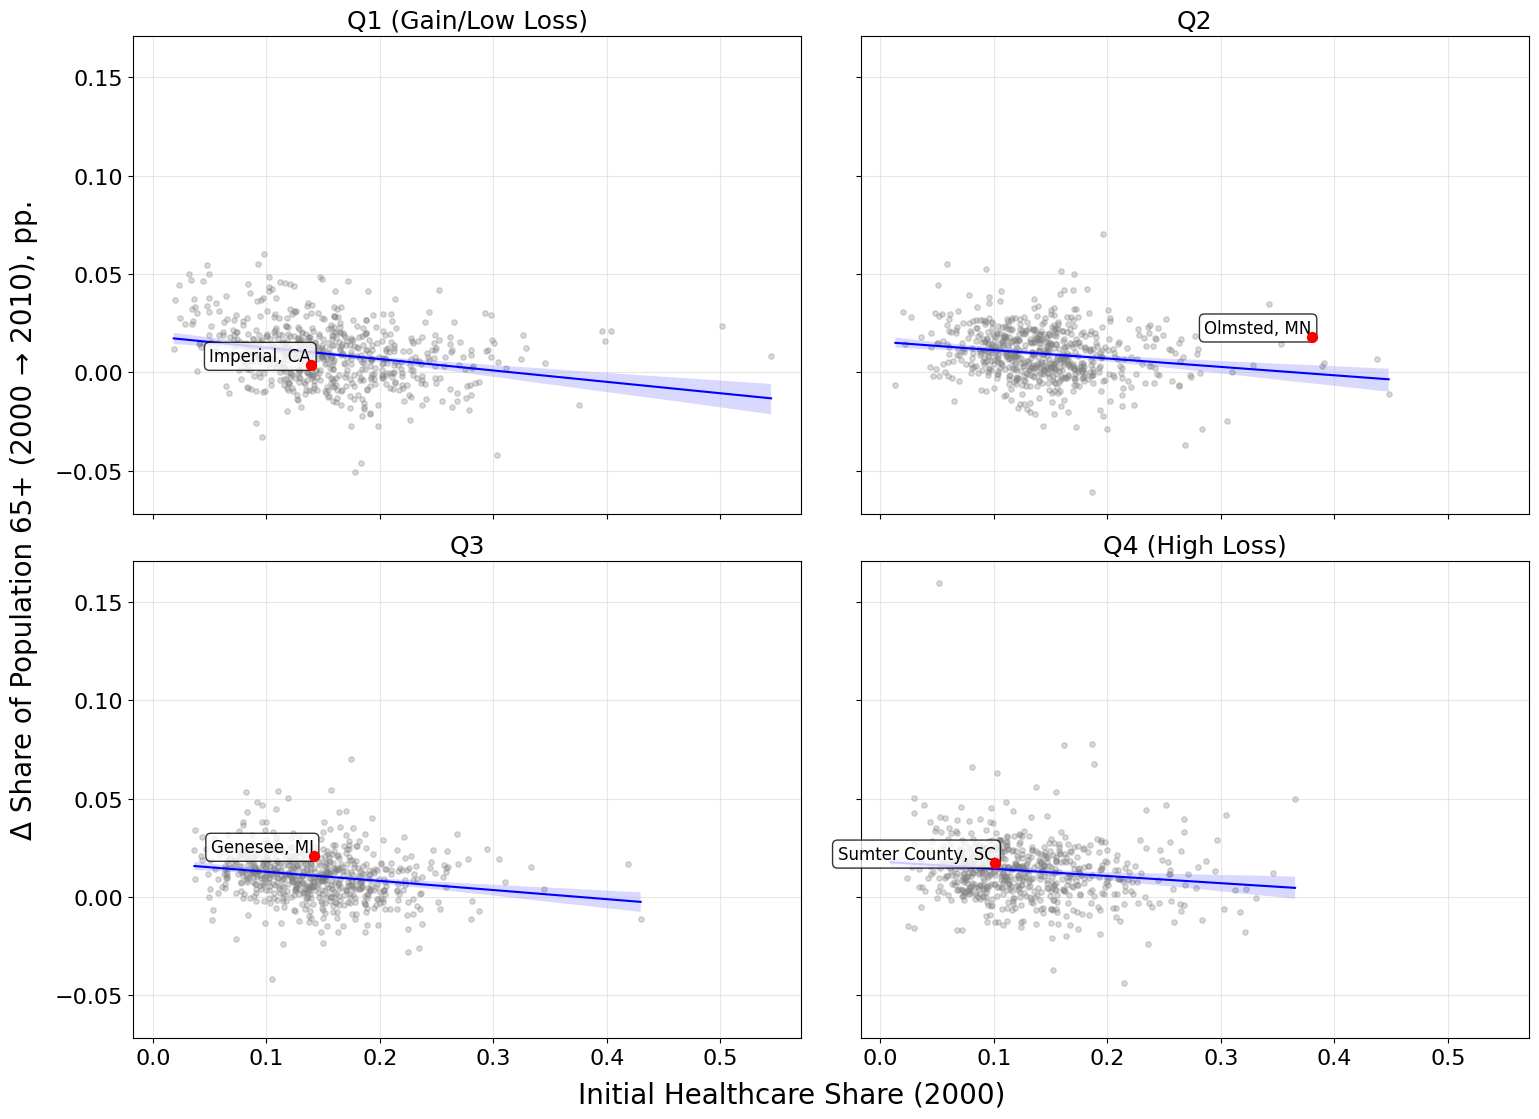


=== Analysis Complete ===


In [105]:
df_reg = panel.replace([np.inf, -np.inf], np.nan).dropna(subset=regvars + ['county_fips', 'NAME']) # Add county_fips and NAME for labeling
df_reg = df_reg[df_reg['ManufShare_2000'] > 0]
#df_reg = df_reg[df_reg['ManufShare_2010'] > 0]
df_reg = df_reg[df_reg['HealthShare_2000'] > 0]


#df_reg = df_reg[df_reg['HealthShare_2010'] > 0]
#question = df_reg.sort_values(by = 'ManufLoss', ascending = True)
#question = question[question['TotalPop_2000']>100000]
#display(question)
#return
print(f"\nCounties in regression after cleaning NAs/Infs: {len(df_reg)}")
df_reg['TotalPop_2000_Thousands'] = df_reg['TotalPop_2000'] / 1000
if len(df_reg) >= 30: 
    model_formula = ("Delta_Share65 ~ ManufLoss + HealthChange + HealthShare_2000 "
                     "+ ManufLoss:HealthShare_2000 + Share65_2000 + TotalPop_2000_Thousands")
    model = smf.ols(model_formula, data=df_reg).fit()
    
    print(model.summary())

    # --- Save regression results to LaTeX ---
    try:
    # Corrected line: removed the 'title' argument
        reg_table = summary_col([model], stars=True, float_format='%0.5f',
                                model_names=['DV: Change in Share 65+, 2000-10'],
                                info_dict={'N': lambda x: "{0:d}".format(int(x.nobs))},
                                regressor_order=model.model.exog_names[1:] + [model.model.exog_names[0]] # Puts Intercept last
                                )
        
        # Clean up the LaTeX table a bit for direct input
        latex_table_str = reg_table.as_latex()
        
        # Add a caption for the table
        table_title = 'Regression of Change in Share of Population 65+ (2000-2010) on Covariates'
      
        caption_str = f"\\caption{{{table_title}}}\n"
        label_str = "\\label{tab:regression_results}\n"
        # Add placement specifier and caption
        if '\\begin{table}' in latex_table_str:
            latex_table_str = latex_table_str.replace('\\begin{table}', f'\\begin{{table}}[htbp]\n{caption_str}{label_str}', 1)
        else: # Failsafe if \begin{table} is not found, though as_latex() should include it.
            latex_table_str = f'\\begin{{table}}[htbp]\n{caption_str}{label_str}{latex_table_str}\\end{{table}}\n'


        latex_table_str = latex_table_str.replace('Dependent variable:','Dependent variable: Delta\\_Share65')
        latex_table_str = latex_table_str.replace('ManufLoss:HealthShare_2000','ManufLoss X HealthShare\\_2000')
        latex_table_str = latex_table_str.replace('\label{}','')
        latex_table_str = latex_table_str.replace('\caption{}','')
        # Add a note about standard errors
        end_tabular_idx = latex_table_str.find('\\end{tabular}')
        if end_tabular_idx != -1:
            note_text = "\\\\\n\\multicolumn{2}{l}{\\footnotesize Standard errors in parentheses.} \\\\\n" + \
                        "\\multicolumn{2}{l}{\\footnotesize $^{*}p<0.1$; $^{**}p<0.05$; $^{***}p<0.01$} \\\\\n"
            latex_table_str = latex_table_str[:end_tabular_idx] + note_text + latex_table_str[end_tabular_idx:]
            string_to_remove = "Standard errors in parentheses. \\newline \n* p<.1, ** p<.05, ***p<.01"
            latex_table_str = latex_table_str.replace(string_to_remove, "")
            
            with open('regression_table.tex', 'w') as f:
                f.write(latex_table_str)
            print("\n✓ Regression table saved as regression_table.tex")

    except Exception as e:
        print(f"Error saving regression table to LaTeX: {e}")

    # --- Summary Statistics ---
    summary_vars = ['Delta_Share65', 'ManufLoss', 'HealthChange', 'HealthShare_2000', 'Share65_2000', 'TotalPop_2000_Thousands']
    desc_stats = df_reg[summary_vars].describe().transpose()
    desc_stats = desc_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'count']]
    desc_stats.columns = ['Mean', 'Std. Dev.', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'N']
    desc_stats['N'] = desc_stats['N'].astype(int) 

    var_labels = {
        'Delta_Share65': '$\\Delta$ Share of Pop. 65+ (2000-10)',
        'ManufLoss': 'Manu. Loss ($\\Delta$ Share, 2000-10)',
        'HealthChange': '$\\Delta$ HC Share (2000-2010)',
        'HealthShare_2000': 'HC Share (2000)',
        'Share65_2000': 'Share of Pop. 65+ (2000)',
        'TotalPop_2000_Thousands': ' Total Pop. (2000, thousands)'
    }
    desc_stats.index = desc_stats.index.map(var_labels)

    try:
        stargazer_format = {
            'Mean': '{:.3f}', 'Std. Dev.': '{:.3f}', 
            'Min': '{:.3f}', 'Q1': '{:.3f}', 'Median': '{:.3f}', 
            'Q3': '{:.3f}', 'Max': '{:.3f}', 'N': '{:d}'
        }
        
        latex_summary_stats = desc_stats.to_latex(
            escape=False, 
            column_format='l' + 'r' * (len(desc_stats.columns)), 
            float_format="%.3f", 
            formatters={col: (lambda x, fmt=fmt: fmt.format(x)) for col, fmt in stargazer_format.items()},
            caption='Summary Statistics of Variables used in Manu. / HC. analysis',
            label='tab:summary_stats',
            header=True,
            index=True,
            multicolumn_format='c' 
        )
        latex_summary_stats = latex_summary_stats.replace('\\begin{table}', '\\begin{table}[htbp]')
        latex_summary_stats = latex_summary_stats.replace('\\begin{tabular}', '\\begin{adjustbox}{max width=\\textwidth}\n\\begin{tabular}')
        latex_summary_stats = latex_summary_stats.replace('\\end{tabular}', '\\end{tabular}\n\\end{adjustbox}')
        
        with open('manu_summary_statistics.tex', 'w') as f:
            
            f.write(latex_summary_stats)
        print("\n✓ Summary statistics table saved as manu_summary_statistics.tex")
    except Exception as e:
        print(f"Error saving summary statistics to LaTeX: {e}")


    # --- Quartile plot of ManufLoss ---
    if df_reg['ManufLoss'].nunique() > 1:
        try:
            df_reg['ManufLoss_Q'] = pd.qcut(
                df_reg['ManufLoss'], 4,
                labels=['Q1 (Gain/Low Loss)','Q2','Q3','Q4 (High Loss)'],
                duplicates='drop' 
            )
            fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True) 
            axes = axes.flatten() 
            
            # FIPS codes for labeling specific counties
            counties_to_label_names = {
                '27109': 'Olmsted, MN', # Mayo Clinic
                '06025' :'Imperial, CA', #.. 
              #  '26163': 'Wayne, MI',   # Detroit
                # --- IDEAS for Q1 (Gain/Low Loss) - you can add these to counties_to_label_selected_fips below ---
               #  '48453': 'Travis, TX',    # Austin (Tech boom, might be Q1/Q2)
               #  '06085': 'Santa Clara, CA', # Silicon Valley (High-tech manf., R&D)
               #  '30031': 'Gallatin, MT', # Bozeman (Growth, diversification)
                # --- IDEAS for Q4 (High Loss) - you can add these to counties_to_label_selected_fips below ---
               #  '39099': 'Mahoning, OH',  # Youngstown (Steel decline)
                 '26049': 'Genesee, MI',   # Flint (Auto decline)
               #  '37025': 'Cabarrus, NC', # Concord/Kannapolis (Textile decline)
                # --- Other previously considered counties (can be added if desired) ---
                # '36061': 'New York, NY',
                # '06037': 'Los Angeles, CA',
                # '39035': 'Cuyahoga, OH',  # Cleveland Clinic
                # '17031': 'Cook, IL',      # Chicago
                # '48201': 'Harris, TX',    # Houston
                # '04013': 'Maricopa, AZ',  # Phoenix
                #  "18035": "Elkhart County, IN",
    #"18087": "LaGrange County, IN",
    #"18109": "Noble County, IN",
    "45085": "Sumter County, SC",
   # "18097": "Marion County, IN"
            }
            
            # Only these will be actively labeled based on your request:
            counties_to_label_selected_fips = list(counties_to_label_names.keys())

            # Prepare data for only the selected labels
            label_data = df_reg[df_reg['county_fips'].isin(counties_to_label_selected_fips)].copy()
            if not label_data.empty:
                 label_data['label_name'] = label_data['county_fips'].map(counties_to_label_names)


            if df_reg['ManufLoss_Q'].nunique() >= 1 :
                grouped_data = df_reg.groupby('ManufLoss_Q', observed=False) 
                
                num_groups = len(grouped_data)
                plot_axes = axes[:num_groups] 

                for i, (q_name, g) in enumerate(grouped_data):
                    if i < len(plot_axes): 
                        ax = plot_axes[i]
                        # General scatter plot for all points in the quartile
                        ax.scatter(g['HealthShare_2000'], g['Delta_Share65'],
                                   alpha=0.3, s=15, color='grey') # Less prominent base points
                        
                        if len(g) > 1: 
                           sns.regplot(
                               data=g, x='HealthShare_2000', y='Delta_Share65', ax=ax,
                               scatter=False, 
                               line_kws={'linewidth': 1.5, 'color': 'blue'} # Changed regression line color for contrast
                           )
                        ax.set_title(f"{q_name}", fontsize=18)
                        ax.grid(alpha=0.3)
                        ax.tick_params(axis='x', labelsize=16) # Adjust labelsize for X-axis ticks
                        ax.tick_params(axis='y', labelsize=16) # Adjust labelsize for Y-axis ticks
                        ax.set_xlabel('')
                        ax.set_ylabel('')
                        # Add labels for specific counties within this quartile
                        # Filter label_data for the current quartile
                        current_q_labels = label_data[label_data['ManufLoss_Q'] == q_name]
                        for idx, row in current_q_labels.iterrows():
                            # Plot the specific point in red
                            ax.scatter(row['HealthShare_2000'], row['Delta_Share65'], color='red', s=50, zorder=5, label=None)
                            ax.text(row['HealthShare_2000'], row['Delta_Share65'], row['label_name'], 
                                    fontsize=12, # Made text larger
                                    color='black',
                                    ha='right', 
                                    va='bottom',
                                    bbox=dict(facecolor='white', alpha=0.8, pad=0.3, edgecolor='black', boxstyle='round,pad=0.3'))


                fig.text(0.5, 0.02, "Initial Healthcare Share (2000)", ha='center', va='center', fontsize=20)
                fig.text(0.02, 0.5, "Δ Share of Population 65+ (2000 → 2010), pp.", ha='center', va='center', rotation='vertical', fontsize=20)
                
                #fig.suptitle("Change in Elderly Population Share vs. Initial Healthcare Share\nby Quartile of Manufacturing Employment Loss (2000-2010)", fontsize=20, y=0.99)
                fig.suptitle("", fontsize=20, y=0.99)
                
                for j in range(num_groups, len(axes)):
                    fig.delaxes(axes[j])

                plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95]) 
                plt.savefig(
                    'county_manufacturing_decline_labeled_2000_2010.png',
                    dpi=300, bbox_inches='tight'
                )
                print("\n✓ Plot saved as county_manufacturing_decline_labeled_2000_2010.png")
                plt.show()
            else:
                print("Not enough unique quartile groups for ManufLoss_Q to generate plot.")

        except ValueError as e_qcut:
            print(f"Could not create quartiles for ManufLoss, skipping plot: {e_qcut}")
        except Exception as e_plot:
             print(f"An error occurred during plotting: {e_plot}")
    else:
        print("ManufLoss has insufficient unique values to create quartiles for plotting.")
else:
    print(f"Not enough data points ({len(df_reg)}) for regression analysis or plotting.")

print("\n=== Analysis Complete ===")

In [83]:
# --- Top and Bottom Counties by Change in Elderly Share ---
print("\n" + "-" * 60)
print("Creating tables for top/bottom counties by elderly share change...")

# Filter for counties with 2000 population >= 100,000
large_counties = panel[panel['TotalPop_2000'] >= 100000].copy()
print(f"Counties with 2000 population >= 100,000: {len(large_counties)}")

# Sort by Delta_Share65
large_counties_sorted = large_counties.sort_values('Delta_Share65', ascending=False)

# Get top 10 and bottom 10
top_10 = large_counties_sorted.head(10).copy()
bottom_10 = large_counties_sorted.tail(10).copy()

# Format the data for nice display
def format_county_table(df, table_type):
    display_df = df[['NAME', 'TotalPop_2000', 'TotalPop_2010', 'Share65_2000', 'Delta_Share65']].copy()
    
    # Format population with commas
    display_df['TotalPop_2000'] = display_df['TotalPop_2000'].apply(lambda x: f"{int(x):,}")
    display_df['TotalPop_2010'] = display_df['TotalPop_2010'].apply(lambda x: f"{int(x):,}")
     
    # Format shares as percentages
    display_df['Share65_2000'] = (display_df['Share65_2000'] * 100).round(2)
   # display_df['Share65_2010'] = (display_df['Share65_2010'] * 100).round(2)
    display_df['Delta_Share65'] = (display_df['Delta_Share65'] * 100).round(2)
    
    # Rename columns for LaTeX
    display_df.columns = [
        'County',
        'Pop. (2000)',
        'Pop. (2010)',
        'Pct. 65+ (2000, \\%)',
      #  'Pct. 65+ (2010, \\%)',
        '$\\Delta$ Share 65+ (pp)'
    ]
    
    # Reset index to get clean numbering
    display_df.reset_index(drop=True, inplace=True)
    display_df.index = display_df.index + 1  # Start from 1 instead of 0
    
    return display_df

# Create formatted tables
top_10_formatted = format_county_table(top_10, 'top')
bottom_10_formatted = format_county_table(bottom_10, 'bottom')

# Save Top 10 table to LaTeX
try:
    top_10_latex = top_10_formatted.to_latex(
        escape=False,
        column_format='cl' + 'r' * (len(top_10_formatted.columns) - 1),
        caption='Top 10 Counties by Increase in Elderly Population Share (2000-2010)',
        label='tab:top10_elderly_increase',
        header=True,
        index=True,
        multicolumn_format='c'
    )
    
    # Add placement specifier and note
    top_10_latex = top_10_latex.replace('\\begin{table}', '\\begin{table}[htbp]')
    
    # Add note about population threshold
    end_tabular_idx = top_10_latex.find('\\end{tabular}')
    if end_tabular_idx != -1:
        note_text = "\\\\\n\\multicolumn{6}{l}{\\footnotesize Note: Limited to counties with population $\\geq$ 100,000 in 2000.} \\\\\n"
        top_10_latex = top_10_latex[:end_tabular_idx] + note_text + top_10_latex[end_tabular_idx:]
    
    with open('top10_elderly_increase.tex', 'w') as f:
        f.write(top_10_latex)
    print("✓ Top 10 table saved as top10_elderly_increase.tex")
    
except Exception as e:
    print(f"Error saving top 10 table to LaTeX: {e}")

# Save Bottom 10 table to LaTeX
try:
    bottom_10_latex = bottom_10_formatted.to_latex(
        escape=False,
        column_format='cl' + 'r' * (len(bottom_10_formatted.columns) - 1),
        caption='Bottom 10 Counties by Change in Elderly Population Share (2000-2010)',
        label='tab:bottom10_elderly_change',
        header=True,
        index=True,
        multicolumn_format='c'
    )
    
    # Add placement specifier and note
    bottom_10_latex = bottom_10_latex.replace('\\begin{table}', '\\begin{table}[htbp]')
    
    # Add note about population threshold
    end_tabular_idx = bottom_10_latex.find('\\end{tabular}')
    if end_tabular_idx != -1:
        note_text = "\\\\\n\\multicolumn{6}{l}{\\footnotesize Note: Limited to counties with population $\\geq$ 100,000 in 2000.} \\\\\n"
        bottom_10_latex = bottom_10_latex[:end_tabular_idx] + note_text + bottom_10_latex[end_tabular_idx:]
    
    with open('bottom10_elderly_change.tex', 'w') as f:
        f.write(bottom_10_latex)
    print("✓ Bottom 10 table saved as bottom10_elderly_change.tex")
    
except Exception as e:
    print(f"Error saving bottom 10 table to LaTeX: {e}")

# Print preview of results
print(f"\nTop 5 counties by elderly share increase:")
print(top_10_formatted.head())
print(f"\nBottom 5 counties by elderly share change:")
print(bottom_10_formatted.head())


------------------------------------------------------------
Creating tables for top/bottom counties by elderly share change...
Counties with 2000 population >= 100,000: 521
✓ Top 10 table saved as top10_elderly_increase.tex
✓ Bottom 10 table saved as bottom10_elderly_change.tex

Top 5 counties by elderly share increase:
                            County Pop. (2000) Pop. (2010)  \
1  Beaufort County, South Carolina     120,937     162,233   
2      Santa Fe County, New Mexico     129,292     144,170   
3      Livingston County, Michigan     156,951     180,967   
4         Marin County, California     247,289     252,409   
5           Douglas County, Oregon     100,399     107,667   

   Pct. 65+ (2000, \%)  $\Delta$ Share 65+ (pp)  
1                15.51                     4.85  
2                10.75                     4.37  
3                 8.31                     3.65  
4                13.52                     3.20  
5                17.82                     3.15  

Bo

In [ ]:
df_reg.county_fips

0       01001
1       01003
2       01005
3       01007
4       01009
        ...  
3112    56035
3113    56037
3114    56039
3115    56041
3116    56043
Name: county_fips, Length: 2628, dtype: object

In [81]:
# --- Top and Bottom Counties by Change in Elderly Count ---
print("\n" + "-" * 60)
print("Creating tables for top/bottom counties by elderly count change...")



panel['Count65_2000'] = panel['Share65_2000'] * panel['TotalPop_2000']
panel['Count65_2010'] = panel['Share65_2010'] * panel['TotalPop_2010']
panel['Delta_Count65'] = panel['Count65_2010'] - panel['Count65_2000'] 



# Filter for counties with 2000 population >= 100,000
large_counties = panel[panel['TotalPop_2000'] >= 100000].copy()
print(f"Counties with 2000 population >= 100,000: {len(large_counties)}")

# Sort by Delta_Count65 (change in elderly count)
large_counties_sorted = large_counties.sort_values('Delta_Count65', ascending=False)

# Get top 10 and bottom 10
top_10 = large_counties_sorted.head(10).copy()
bottom_10 = large_counties_sorted.tail(10).copy()
bottom_10=bottom_10.iloc[::-1]
# Format the data for nice display
def format_county_table(df, table_type):
    display_df = df[['NAME', 'TotalPop_2000', 'TotalPop_2010', 'Count65_2000', 'Delta_Count65']].copy()
    
    # Format all population numbers with commas
    display_df['TotalPop_2000'] = display_df['TotalPop_2000'].apply(lambda x: f"{int(x):,}")
    display_df['TotalPop_2010'] = display_df['TotalPop_2010'].apply(lambda x: f"{int(x):,}")
    display_df['Count65_2000'] = display_df['Count65_2000'].apply(lambda x: f"{int(x):,}")
    #display_df['Count65_2010'] = display_df['Count65_2010'].apply(lambda x: f"{int(x):,}")
    display_df['Delta_Count65'] = display_df['Delta_Count65'].apply(lambda x: f"{int(x):,}")
    
    # Rename columns for LaTeX
    display_df.columns = [
        'County',
        'Pop. (2000)',
        'Pop. (2010)',
        'Pop. 65+ (2000)',
       # 'Pop. 65+ (2010)',
        '$\\Delta$ Count 65+'
    ]
    
    # Reset index to get clean numbering
    display_df.reset_index(drop=True, inplace=True)
    display_df.index = display_df.index + 1  # Start from 1 instead of 0
    
    return display_df

# Create formatted tables
top_10_formatted = format_county_table(top_10, 'top')
bottom_10_formatted = format_county_table(bottom_10, 'bottom')

# Save Top 10 table to LaTeX
try:
    top_10_latex = top_10_formatted.to_latex(
        escape=False,
        column_format='cl' + 'r' * (len(top_10_formatted.columns) - 1),
        caption='Top 10 Counties by Increase in Elderly Population Count (2000-2010)',
        label='tab:top10_elderly_count_increase',
        header=True,
        index=True,
        multicolumn_format='c'
    )
    
    # Add placement specifier and note
    top_10_latex = top_10_latex.replace('\\begin{table}', '\\begin{table}[htbp]')
    
    # Add note about population threshold
    end_tabular_idx = top_10_latex.find('\\end{tabular}')
    if end_tabular_idx != -1:
        note_text = "\\\\\n\\multicolumn{6}{l}{\\footnotesize Note: Limited to counties with population $\\geq$ 100,000 in 2000.} \\\\\n"
        top_10_latex = top_10_latex[:end_tabular_idx] + note_text + top_10_latex[end_tabular_idx:]
    
    with open('top10_elderly_count_increase.tex', 'w') as f:
        f.write(top_10_latex)
    print("✓ Top 10 count table saved as top10_elderly_count_increase.tex")
    
except Exception as e:
    print(f"Error saving top 10 count table to LaTeX: {e}")

# Save Bottom 10 table to LaTeX
try:
    bottom_10_latex = bottom_10_formatted.to_latex(
        escape=False,
        column_format='cl' + 'r' * (len(bottom_10_formatted.columns) - 1),
        caption='Bottom 10 Counties by Change in Elderly Population Count (2000-2010)',
        label='tab:bottom10_elderly_count_change',
        header=True,
        index=True,
        multicolumn_format='c'
    )
    
    # Add placement specifier and note
    bottom_10_latex = bottom_10_latex.replace('\\begin{table}', '\\begin{table}[htbp]')
    
    # Add note about population threshold
    end_tabular_idx = bottom_10_latex.find('\\end{tabular}')
    if end_tabular_idx != -1:
        note_text = "\\\\\n\\multicolumn{6}{l}{\\footnotesize Note: Limited to counties with population $\\geq$ 100,000 in 2000.} \\\\\n"
        bottom_10_latex = bottom_10_latex[:end_tabular_idx] + note_text + bottom_10_latex[end_tabular_idx:]
    
    with open('bottom10_elderly_count_change.tex', 'w') as f:
        f.write(bottom_10_latex)
    print("✓ Bottom 10 count table saved as bottom10_elderly_count_change.tex")
    
except Exception as e:
    print(f"Error saving bottom 10 count table to LaTeX: {e}")

# Print preview of results
print(f"\nTop 5 counties by elderly count increase:")
print(top_10_formatted.head())
print(f"\nBottom 5 counties by elderly count change:")
print(bottom_10_formatted.head())


------------------------------------------------------------
Creating tables for top/bottom counties by elderly count change...
Counties with 2000 population >= 100,000: 521
✓ Top 10 count table saved as top10_elderly_count_increase.tex
✓ Bottom 10 count table saved as bottom10_elderly_count_change.tex

Top 5 counties by elderly count increase:
                           County Pop. (2000) Pop. (2010) Pop. 65+ (2000)  \
1  Los Angeles County, California   9,519,338   9,818,605         926,673   
2        Maricopa County, Arizona   3,072,149   3,817,117         358,979   
3            Harris County, Texas   3,400,578   4,092,459         252,895   
4            Clark County, Nevada   1,375,765   1,951,269         146,899   
5       Orange County, California   2,846,289   3,010,232         280,763   

  $\Delta$ Count 65+  
1            139,026  
2            103,662  
3             80,592  
4             73,546  
5             68,914  

Bottom 5 counties by elderly count change:
       

In [ ]:
panel[['county_fips', 'Delta_Count65','Delta_Share65']]

,county_fips,Delta_Count65,Delta_Share65
0,01001,2095.0,0.018033
1,01003,8865.0,0.013149
2,01005,36.0,0.008991
3,01007,493.0,0.010952
4,01009,1881.0,0.018693
...,...,...,...
3113,56037,634.0,0.003163
3114,56039,834.0,0.029269
3115,56041,496.0,0.018939
3116,56043,192.0,0.017961



✓ Plot saved as delta_count_vs_share_analysis.png


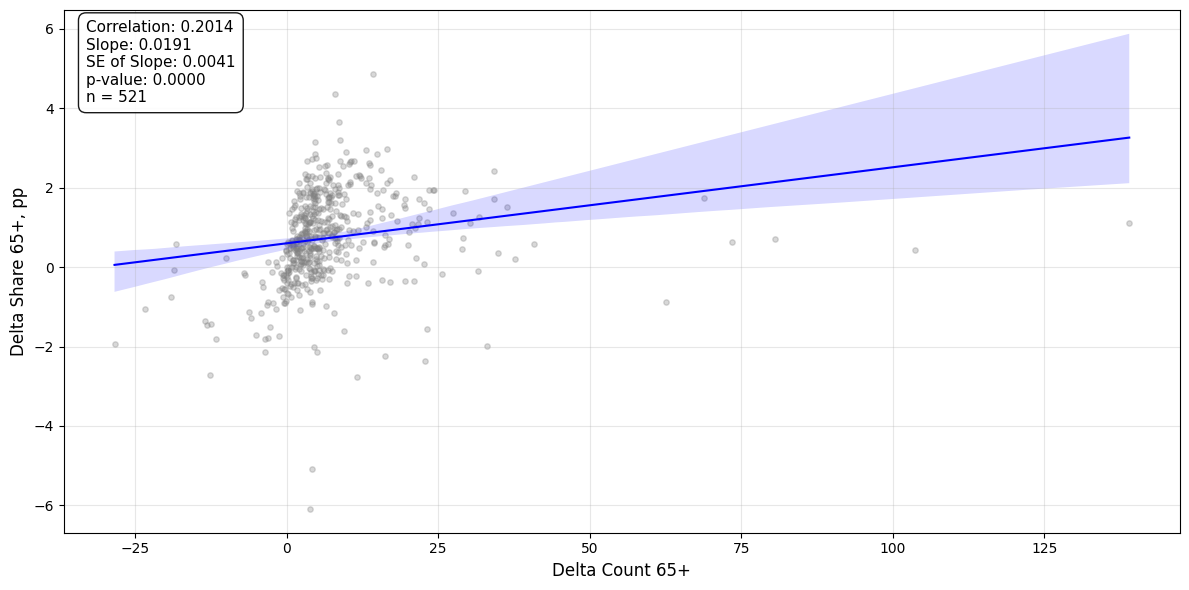


✓ Plot saved as HealthOld2000.png


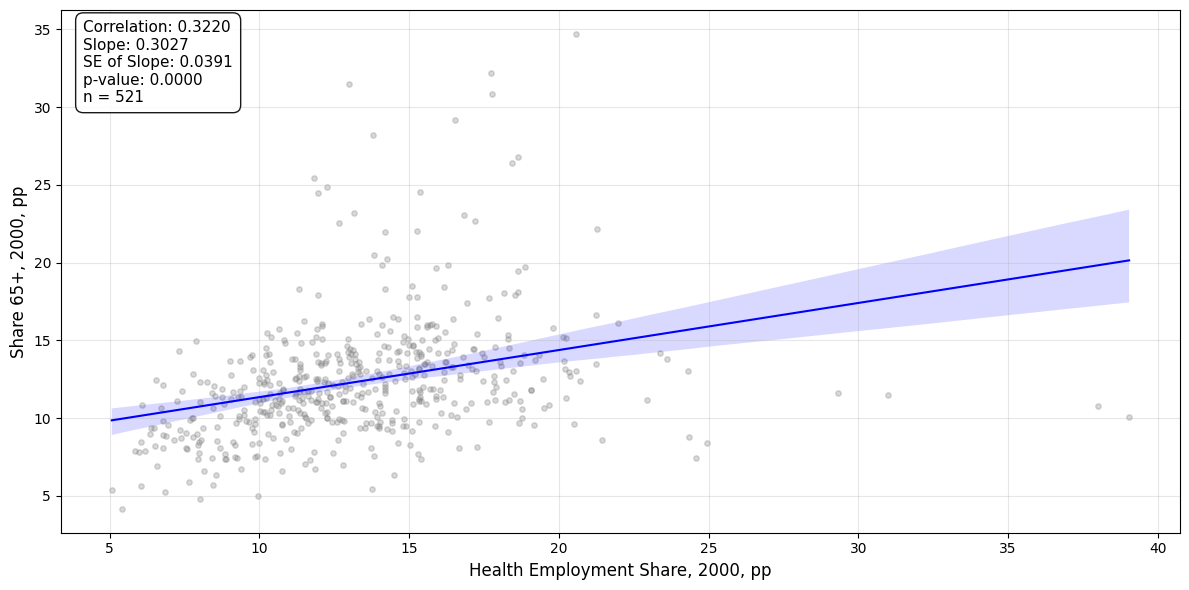


✓ Plot saved as HealthOld2010.png


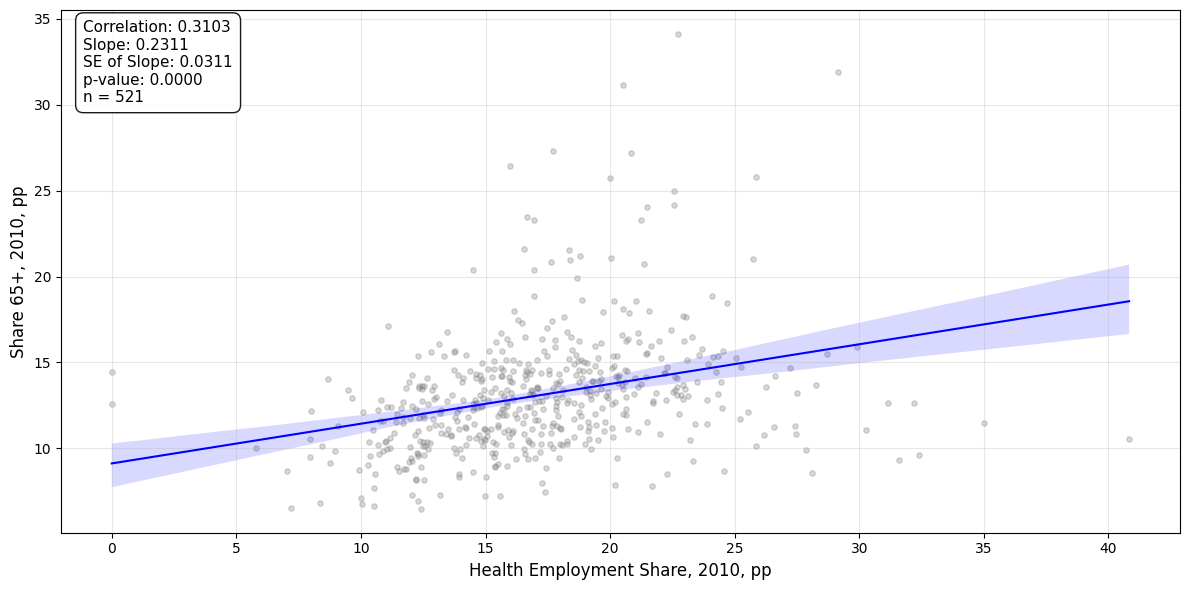


✓ Plot saved as share_change_65.png


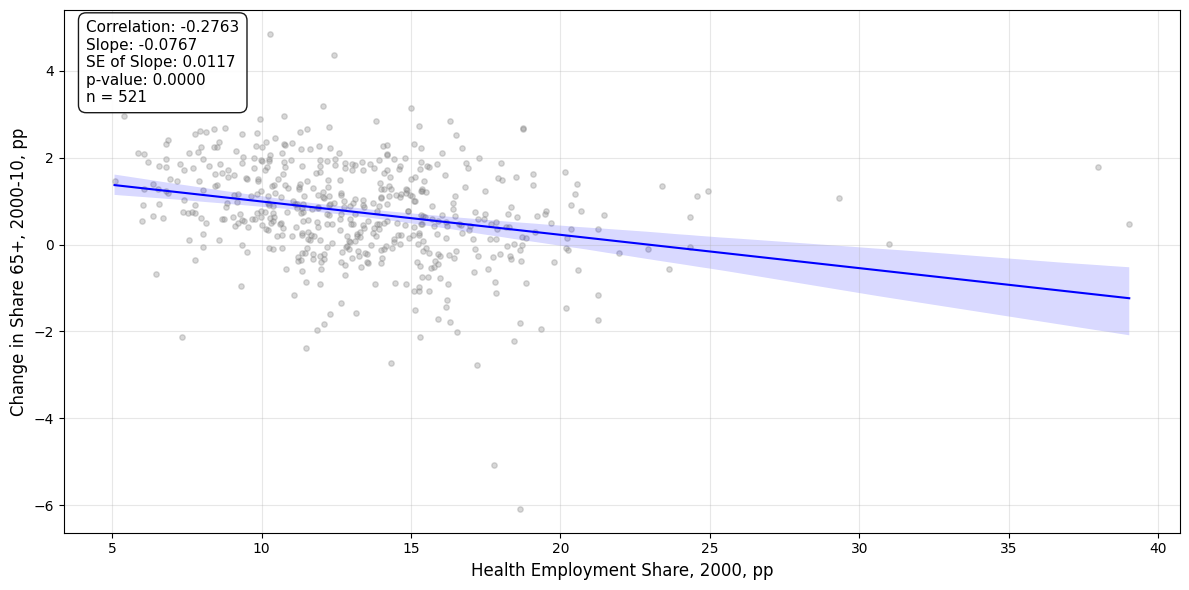

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd

# Assuming your dataframe is called 'df' and has columns 'Delta_Count05' and 'Delta_Share65'
# Replace 'df' with your actual dataframe name

def plot_delta_analysis(df, x_col='Delta_Count65', 
                        x_name = 'Delta Count 65+',
                        y_col='Delta_Share65',
                        y_name = "Delta Share 65+, pp",
                          filename = 'delta_count_vs_share_analysis.png'):
    """
    Plot DeltaCount vs DeltaShares with regression statistics
    
    Parameters:
    df: DataFrame containing the data
    x_col: column name for x-axis (DeltaCount)
    y_col: column name for y-axis (DeltaShares)
    """
    df = df.copy()
    if 'Count' in x_name:
        df[x_col] =  df[x_col] / 1000
    if 'Share' in y_name:
        df[y_col] = df[y_col]*100
    if 'Share' in x_name:
        df[x_col] = df[x_col]*100
    # Remove any NaN values for clean analysis
    clean_data = df[[x_col, y_col]].dropna()
    
    # Calculate regression statistics
    slope, intercept, r_value, p_value, std_err = stats.linregress(clean_data[x_col], clean_data[y_col])
    correlation = r_value
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Scatter plot for all points
    ax.scatter(clean_data[x_col], clean_data[y_col], 
               alpha=0.3, s=15, color='grey')
    
    # Add regression line
    sns.regplot(data=clean_data, x=x_col, y=y_col, ax=ax,
                scatter=False,
                line_kws={'linewidth': 1.5, 'color': 'blue'})
    
    # Add grid
    ax.grid(alpha=0.3)
    
    # Set labels and title
    ax.set_xlabel(x_name, fontsize=12)
    ax.set_ylabel(y_name, fontsize=12)
    #ax.set_title("Change in Count vs. Change in Share of Population 65+, 2000-10", fontsize=14)
    
    # Add statistics text box
    stats_text = f"""Correlation: {correlation:.4f}
Slope: {slope:.4f}
SE of Slope: {std_err:.4f}
p-value: {p_value:.4f}
n = {len(clean_data)}"""
    
    # Position the text box in the upper left or wherever there's space
    ax.text(0.02, 0.98, stats_text, 
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.9, pad=0.5, 
                     edgecolor='black', boxstyle='round,pad=0.5'))
    
    # Tight layout
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(filename, 
                dpi=300, bbox_inches='tight')
    
    print(f"\n✓ Plot saved as {filename}")
    
    plt.show()
    
    return correlation, slope, std_err

# Example usage:
correlation, slope, se_slope = plot_delta_analysis(large_counties)
correlation, slope, se_slope = plot_delta_analysis(large_counties, 'HealthShare_2000', 'Health Employment Share, 2000, pp' , 'Share65_2000', 'Share 65+, 2000, pp', 'HealthOld2000.png')
correlation, slope, se_slope = plot_delta_analysis(large_counties, 'HealthShare_2010', 'Health Employment Share, 2010, pp' , 'Share65_2010', 'Share 65+, 2010, pp' ,'HealthOld2010.png')

correlation, slope, se_slope = plot_delta_analysis(large_counties, 'HealthShare_2000', 'Health Employment Share, 2000, pp' , 'Delta_Share65', 'Change in Share 65+, 2000-10, pp' ,'share_change_65.png')
# If your columns have different names, specify them:
# correlation, slope, se_slope = plot_delta_analysis(df, x_col='your_x_column', y_col='your_y_column')

In [103]:
large_counties

,county_fips,NAME,TotalPop_2000,Share65_2000,ManufShare_2000,HealthShare_2000,TotalPop_2010,Share65_2010,ManufShare_2010,HealthShare_2010,Delta_Share65,ManufChange,HealthChange,ManufLoss,Count65_2000,Count65_2010,Delta_Count65
1,01003,"Baldwin County, Alabama",140415,0.154563,0.142841,0.112610,182265,0.167712,0.070763,0.134451,0.013149,-0.072078,0.021842,0.072078,21703.0,30568.0,8865.0
7,01015,"Calhoun County, Alabama",112249,0.141400,0.272148,0.131900,118572,0.143288,0.162188,0.167952,0.001889,-0.109960,0.036052,0.109960,15872.0,16990.0,1118.0
27,01055,"Etowah County, Alabama",103459,0.160063,0.232465,0.156005,104430,0.158077,0.155788,0.236769,-0.001986,-0.076677,0.080764,0.076677,16560.0,16508.0,-52.0
36,01073,"Jefferson County, Alabama",662047,0.136372,0.099936,0.133262,658466,0.131279,0.077348,0.169075,-0.005093,-0.022589,0.035813,0.022589,90285.0,86443.0,-3842.0
40,01081,"Lee County, Alabama",115092,0.081126,0.213504,0.137399,140247,0.090669,0.137124,0.155142,0.009542,-0.076380,0.017743,0.076380,9337.0,12716.0,3379.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3076,55105,"Rock County, Wisconsin",152307,0.127341,0.277830,0.113361,160331,0.135713,0.148885,0.170559,0.008372,-0.128945,0.057198,0.128945,19395.0,21759.0,2364.0
3082,55117,"Sheboygan County, Wisconsin",112646,0.139659,0.397078,0.096876,115507,0.145628,0.314242,0.137223,0.005969,-0.082836,0.040347,0.082836,15732.0,16821.0,1089.0
3089,55131,"Washington County, Wisconsin",117493,0.112449,0.333854,0.100019,131887,0.134987,0.256371,0.123446,0.022538,-0.077484,0.023427,0.077484,13212.0,17803.0,4591.0
3090,55133,"Waukesha County, Wisconsin",360767,0.120393,0.220852,0.085023,389891,0.142830,0.185290,0.120644,0.022436,-0.035562,0.035621,0.035562,43434.0,55688.0,12254.0


In [93]:
'Count' in 'Delta Count 65+'

True